In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib_inline
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import special
from scipy.optimize import Bounds, NonlinearConstraint

from FFTOptionPricing import OptionPricingFFT, Calibration
from run_differential_evol import run_differential_evolution

In [3]:
%matplotlib inline

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
%config InlineBackend.figure_formats = ['retina']

## 1. Importing and pre-processing of data

In [4]:
filepaths_options = {
    'ABB': './Option Data/0#ABBE*.EX.xlsx',
    'CFR': './Option Data/0#CFRE*.EX.xlsx',
    'HOLN': './Option Data/0#HOLE*.EX.xlsx',
    'NESN': './Option Data/0#NESE*.EX.xlsx',
    'NOVN': './Option Data/0#NOVE*.EX.xlsx',
    'ROG': './Option Data/0#ROGE*.EX.xlsx',
    'SCMN': './Option Data/0#SCME*.EX.xlsx',
    'SRENH': './Option Data/0#SREE*.EX.xlsx',
    'UBSN': './Option Data/0#UBSE*.EX.xlsx',
    'ZURN': './Option Data/0#ZURE*.EX.xlsx',
}

filepaths_stocks_and_dividends = {
    'ABB': './Stock Data/ABBN.S.xlsx',
    'CFR': './Stock Data/CFR.S.xlsx',
    'HOLN': './Stock Data/HOLN.S.xlsx',
    'NESN': './Stock Data/NESN.S.xlsx',
    'NOVN': './Stock Data/NOVN.S.xlsx',
    'ROG': './Stock Data/ROPC.S.xlsx',
    'SCMN': './Stock Data/SCMN.S.xlsx',
    'SRENH': './Stock Data/SRENH.S.xlsx',
    'UBSN': './Stock Data/UBSG.S.xlsx',
    'ZURN': './Stock Data/ZURN.S.xlsx',
}

tickers = [key for key, _ in filepaths_options.items()]

In [5]:
stock_prices = []
option_dfs = {}

for key, value in filepaths_options.items():
    df = pd.read_excel(value)

    df['time_to_maturity_years'] = pd.to_numeric(df['time_to_maturity_years'], errors='coerce')
    df['strike'] = pd.to_numeric(df['strike'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['vega'] = pd.to_numeric(df['vega'], errors='coerce').dropna()

    df = df[df['vega'] != 0]
    df = df[df['strike'] > 1]
    df = df[(df['time_to_maturity_years'] > 0.01) & (df['time_to_maturity_years'] < 1.0)]

    option_dfs[key] = df
    stock_prices.append(df['S0'].unique().item())

In [6]:
def project_dividends(dividends_arr):
    projected_dividend = dividends_arr[-1]*np.clip(dividends_arr[-1]/dividends_arr[-2], 0, 2)
    return projected_dividend

In [7]:
r = -0.04 * 1e-2  # SARON risk-free rate per 2026-05-06

projected_dividends = []
projected_time_to_next_dividend = []

for key, value in filepaths_stocks_and_dividends.items():
    df_option = option_dfs[key].copy()
    START_DATE = pd.to_datetime(df_option['START_DATE'].unique().item())

    df_dividends = pd.read_excel(value, sheet_name='Dividends')

    df_dividends['Dividend Ex Date'] = pd.to_datetime(df_dividends['Dividend Ex Date'])
    df_dividends['Gross Dividend Amount'] = pd.to_numeric(df_dividends['Gross Dividend Amount'], errors='coerce')
    df_dividends = df_dividends.dropna(subset=['Dividend Ex Date', 'Gross Dividend Amount'])

    df_dividends = df_dividends[df_dividends['Dividend Ex Date'] <= START_DATE]
    df_dividends = df_dividends.sort_values('Dividend Ex Date')

    df_dividends['dividend_year'] = df_dividends['Dividend Ex Date'].dt.year
    df_dividends_annual = df_dividends.groupby('dividend_year', as_index=False).agg({'Gross Dividend Amount': 'sum', 'Dividend Ex Date': 'max'}).sort_values('Dividend Ex Date')

    dividends_arr = df_dividends_annual['Gross Dividend Amount'].to_numpy()

    projected_dividend = project_dividends(dividends_arr)

    LAST_EX_DATE = df_dividends_annual.iloc[-1]['Dividend Ex Date']
    NEXT_EX_DATE = LAST_EX_DATE + pd.DateOffset(years=1)

    while NEXT_EX_DATE <= START_DATE:
        NEXT_EX_DATE += pd.DateOffset(years=1)

    time_to_next_dividend = (NEXT_EX_DATE - START_DATE).days/365

    option_dfs[key]['projected_dividend'] = projected_dividend
    option_dfs[key]['time_to_next_dividend_years'] = time_to_next_dividend

    S0 = float(df_option['S0'].unique().item())
    PV_dividend = projected_dividend * np.exp(-r * time_to_next_dividend)
    S0_eff = S0 - PV_dividend

    option_dfs[key]['drift'] = r
    mask = option_dfs[key]['time_to_maturity_years'] > time_to_next_dividend
    option_dfs[key].loc[mask,'drift'] = r + np.log(S0_eff/S0)/option_dfs[key].loc[mask,'time_to_maturity_years']

    projected_dividends.append(float(projected_dividend))
    projected_time_to_next_dividend.append(time_to_next_dividend)

## 2. Calibration

### 2.1 Differential evolution

In [8]:
CarrMadan_params = [0.25, 2**12, 1.5]
VG_params_init = np.array([0.25, -0.15, 0.001]) #sigma, theta, nu

alpha = CarrMadan_params[2]

def martingale_margin(VG_params):
    sigma, theta, nu = VG_params
    return 1 - theta*nu - 0.5*nu*sigma**2

def alpha_margin(VG_params):
    sigma, theta, nu = VG_params
    return np.sqrt(theta**2/sigma**4 + 2/(nu*sigma**2)) - theta/sigma**2 - 1

In [9]:
r = -0.04*1e-2
strategy = 'rand2bin'

#sigma, theta, nu
lower = np.array([0.05, -2.0, 1e-3], dtype=float)
upper = np.array([0.6, -1e-6, 0.5], dtype=float)
bounds = Bounds(lower, upper)

MG_constraint = NonlinearConstraint(martingale_margin, lb=1e-6, ub=np.inf)
alpha_constraint = NonlinearConstraint(alpha_margin, lb=alpha+1e-6, ub=np.inf)

constraint = (MG_constraint, alpha_constraint)

In [10]:
results_FFT = []
calibrations_FFT = []

for i, ticker in enumerate(tickers):
    print(f'------------------------------------------------------------------ Processing stock: {ticker} ------------------------------------------------------------------')
    print()

    option_df = option_dfs[ticker]
    S0 = stock_prices[i]

    print(f'S0 = {S0}')
    print(f'Length of data: {len(option_df)}')
    print()

    calibration_FFT = Calibration(
        df=option_df, 
        S0=S0,
        r=r,
        VG_params_init=VG_params_init,
        CarrMadan_params=CarrMadan_params
    )

    result_FFT = run_differential_evolution(
        class_=calibration_FFT,
        args=(),
        bounds=bounds,
        strategy=strategy,
        x0=VG_params_init,
        constraint=constraint
    )

    calibrations_FFT.append(calibration_FFT)
    results_FFT.append(result_FFT)

    print()
    print(f'Optimal parameters [sigma, theta, nu]: {result_FFT.x}')
    print(f'Objective value: {result_FFT.fun}')
    print()

------------------------------------------------------------------ Processing stock: ABB ------------------------------------------------------------------

S0 = 82.52
Length of data: 224

differential_evolution step 1: f(x)= 7.305686690376956
[DE] conv=0.000 best_x≈[ 2.65008974e-01 -1.13706901e+00  1.07003252e-03]
differential_evolution step 2: f(x)= 7.305686690376956
[DE] conv=0.000 best_x≈[ 2.65008974e-01 -1.13706901e+00  1.07003252e-03]
differential_evolution step 3: f(x)= 7.282377939891838
[DE] conv=0.000 best_x≈[ 0.26571235 -0.52623265  0.08760202]
differential_evolution step 4: f(x)= 7.282377939891838
[DE] conv=0.000 best_x≈[ 0.26571235 -0.52623265  0.08760202]
differential_evolution step 5: f(x)= 6.849528205419292
[DE] conv=0.000 best_x≈[ 0.26609524 -0.52589007  0.06293504]
differential_evolution step 6: f(x)= 6.849528205419292
[DE] conv=0.000 best_x≈[ 0.26609524 -0.52589007  0.06293504]
differential_evolution step 7: f(x)= 6.1297955253951315
[DE] conv=0.000 best_x≈[ 0.2700358 

### 2.2 Model evaluation

In [11]:
def interpolate_fft_prices(K_grid, C_grid, strikes):
    prices = np.full(len(strikes), np.nan, dtype=float)

    in_range = (strikes >= K_grid[0]) & (strikes <= K_grid[-1])
    if not np.any(in_range):
        return prices

    strikes_use = strikes[in_range]
    left_idx = np.searchsorted(K_grid, strikes_use, side='right') - 1
    left_idx = np.clip(left_idx, 0, len(K_grid) - 2)

    K_left = K_grid[left_idx]
    K_right = K_grid[left_idx + 1]
    weight = (strikes_use - K_left) / (K_right - K_left)

    C_left = C_grid[left_idx]
    C_right = C_grid[left_idx + 1]
    prices[in_range] = (1.0 - weight) * C_left + weight * C_right

    return prices

def model_prices_FFT(df, S0, r, VG_params, CarrMadan_params):
    df = df.copy()
    #mu_Q = float(np.nanmedian(df['drift']))
    mu_Q = r

    df['FFT_price'] = np.nan
    df['FFT_error'] = np.nan
    df['FFT_rel_error'] = np.nan

    maturities = np.sort(df['time_to_maturity_years'].dropna().unique())

    for T in maturities:
        pricer = OptionPricingFFT(S0=S0, r=r, mu_Q=mu_Q, T=T, VG_params=VG_params, CarrMadan_params=CarrMadan_params)

        K_grid, C_grid = pricer.price_options_FFT()

        rows = np.isclose(df['time_to_maturity_years'].to_numpy(), T, atol=1e-10, rtol=0.0)
        strikes = df.loc[rows, 'strike'].to_numpy(dtype=float)
        market_prices = df.loc[rows, 'price'].to_numpy(dtype=float)

        model_prices = interpolate_fft_prices(K_grid, C_grid, strikes)

        df.loc[rows, 'FFT_price'] = model_prices
        df.loc[rows, 'FFT_error'] = model_prices - market_prices
        df.loc[rows, 'FFT_rel_error'] = (model_prices - market_prices) / market_prices

    return df

def error_metrics(df, price_col='FFT_price', market_col='price'):
    y_true = pd.to_numeric(df[market_col], errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(df[price_col], errors='coerce').to_numpy(dtype=float)

    ok = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0.0)
    if not np.any(ok):
        return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'n_obs': 0}

    err = y_pred[ok] - y_true[ok]
    rel_err = err / y_true[ok]

    return {
        'MAE': float(np.mean(np.abs(err))),
        'RMSE': float(np.sqrt(np.mean(err**2))),
        'MAPE': float(100.0 * np.mean(np.abs(rel_err))),
        'n_obs': int(np.sum(ok)),
    }

In [12]:
errors = []
dfs = []

for i, ticker in enumerate(tickers):
    S0 = stock_prices[i]
    VG_params = results_FFT[i].x

    df = model_prices_FFT(option_dfs[ticker], S0, r, VG_params, CarrMadan_params)
    df.insert(0, 'TKR', ticker)

    dfs.append(df)
    errors.append({'TKR': ticker, **error_metrics(df)})

errors_df = pd.DataFrame(errors)
print(errors_df)

     TKR        MAE       RMSE       MAPE  n_obs
0    ABB   0.877342   0.994201  10.190025    224
1    CFR   0.737616   0.954098   8.584948    261
2   HOLN   0.957861   1.144918  12.910729    175
3   NESN   0.416354   0.520442   9.890182    166
4   NOVN   0.359792   0.762351   3.770746    165
5    ROG   2.451185   2.761999   5.526879    194
6   SCMN   4.075758   4.689161   8.511140    156
7  SRENH   0.488226   0.606148   9.698850    147
8   UBSN   0.442100   0.531315  12.322032    169
9   ZURN  10.598091  13.203454  21.870520    203


In [13]:
rows = []

for ticker, S0, result in zip(tickers, stock_prices, results_FFT):
    sigma, theta, nu = result.x

    A = np.sqrt((0.5*theta*nu)**2 + 0.5*nu*sigma**2)

    C = 1/nu
    G = 1/(A - 0.5*theta*nu)
    M = 1/(A + 0.5*theta*nu)

    rows.append({
        'TKR': ticker,
        'S0': S0,
        'r': r,
        'C': C,
        'G': G,
        'M': M,
        'sigma': sigma,
        'theta': theta,
        'nu': nu,
        'objective_value': result.fun,
        'success': result.success,
        'message': str(result.message),
        'nit': getattr(result, 'nit', np.nan),
        'nfev': getattr(result, 'nfev', np.nan),
    })

df_FFT = pd.DataFrame(rows)
print(df_FFT)

     TKR      S0       r          C          G          M     sigma     theta  \
0    ABB   82.52 -0.0004   9.291796  11.755032  21.361711  0.272041 -0.355478   
1    CFR  154.00 -0.0004  76.961558  41.114587  41.114717  0.301756 -0.000006   
2   HOLN   75.56 -0.0004  11.682712  15.253887  24.100477  0.252106 -0.281134   
3   NESN   76.71 -0.0004  15.339589  20.800683  39.535737  0.193147 -0.349463   
4   NOVN  116.18 -0.0004  28.642719  32.079512  43.187667  0.203343 -0.229651   
5    ROG  318.60 -0.0004  82.005976  54.957042  60.160457  0.222726 -0.129062   
6   SCMN  678.50 -0.0004   2.114152   7.256498  17.020383  0.185027 -0.167133   
7  SRENH  120.90 -0.0004  16.665686  21.327332  33.407383  0.216290 -0.282561   
8   UBSN   35.69 -0.0004  15.649461  17.335430  33.118477  0.233487 -0.430215   
9   ZURN  560.80 -0.0004   9.990483  30.197247  38.938256  0.130358 -0.074268   

         nu  objective_value  success                                message  \
0  0.107622         6.105748

### 2.3 Plots

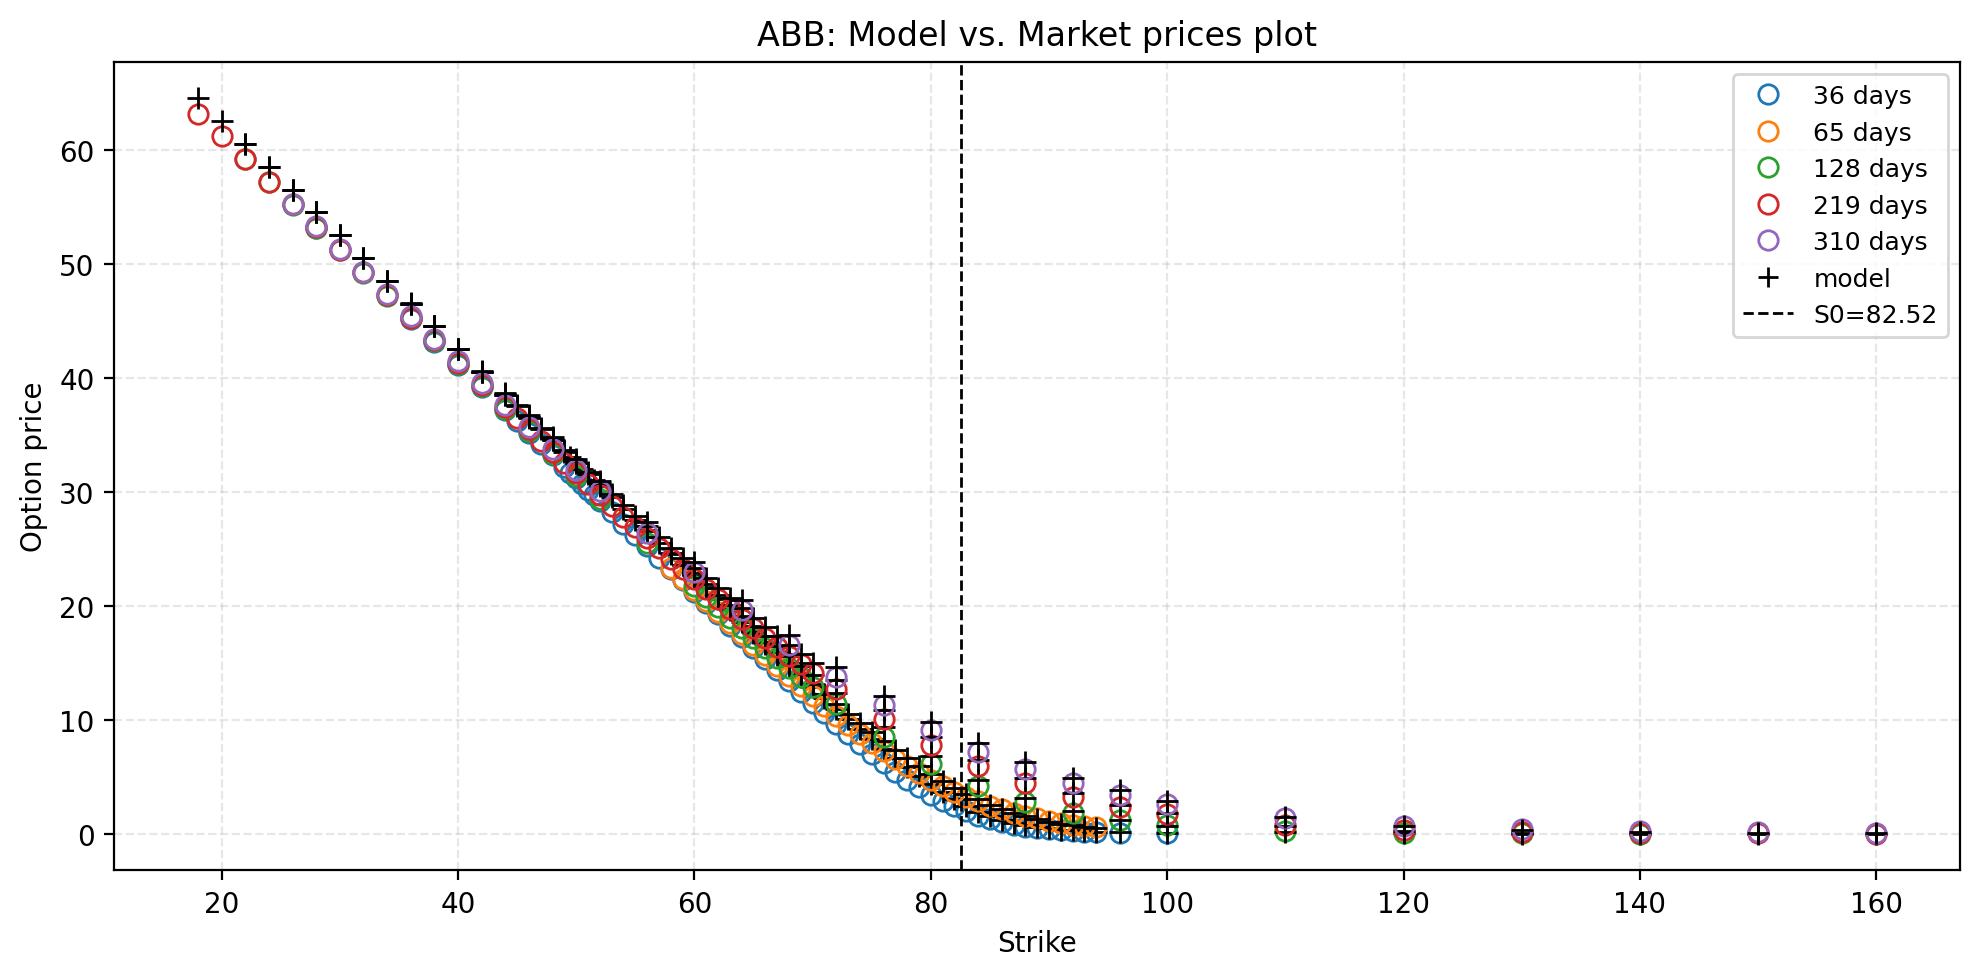

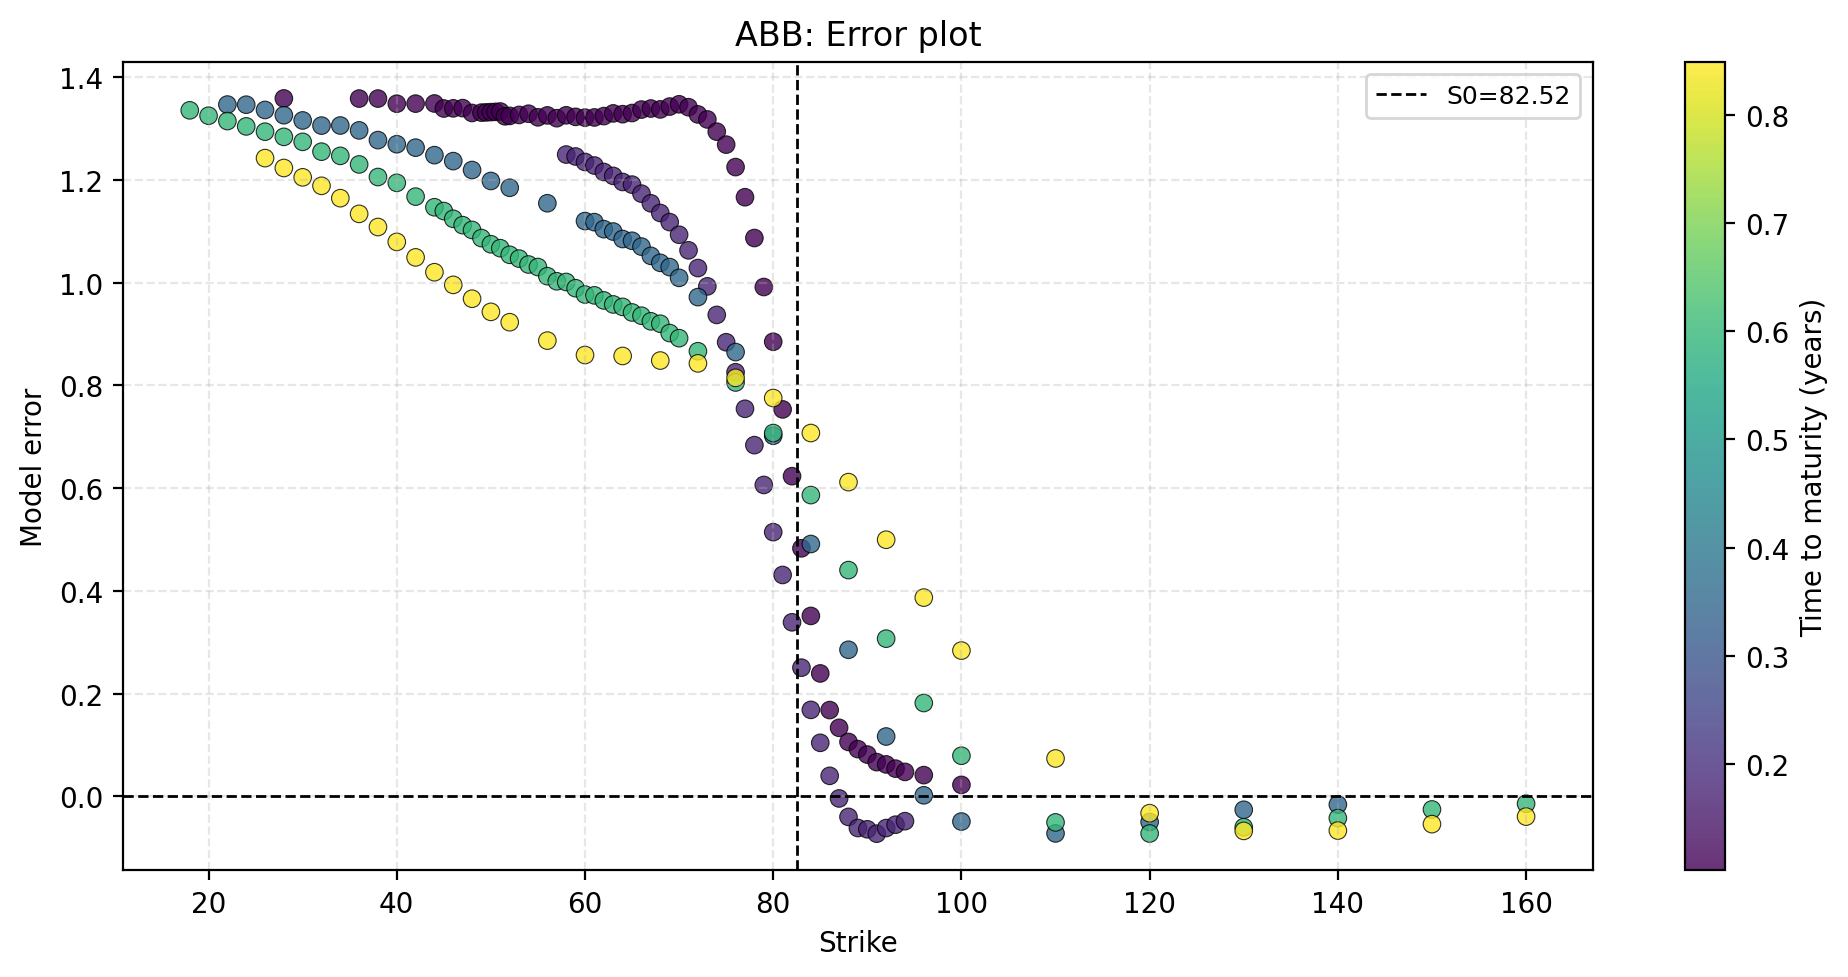

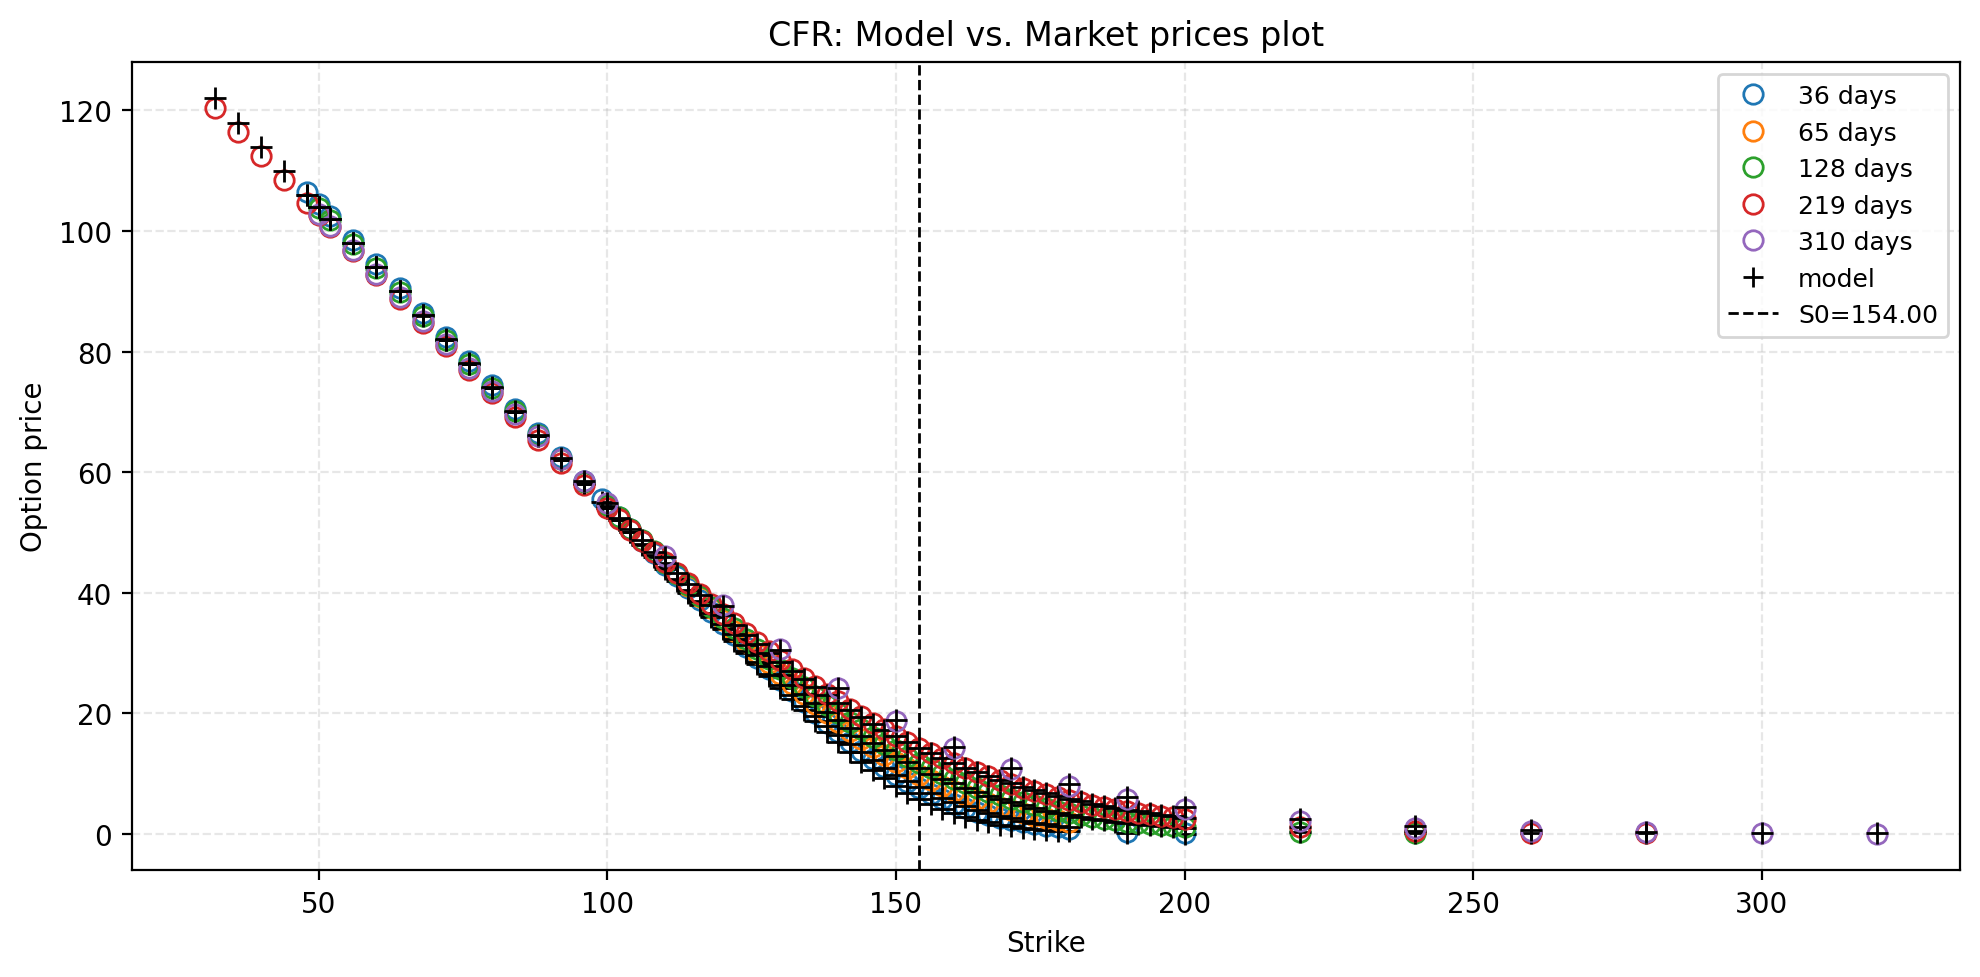

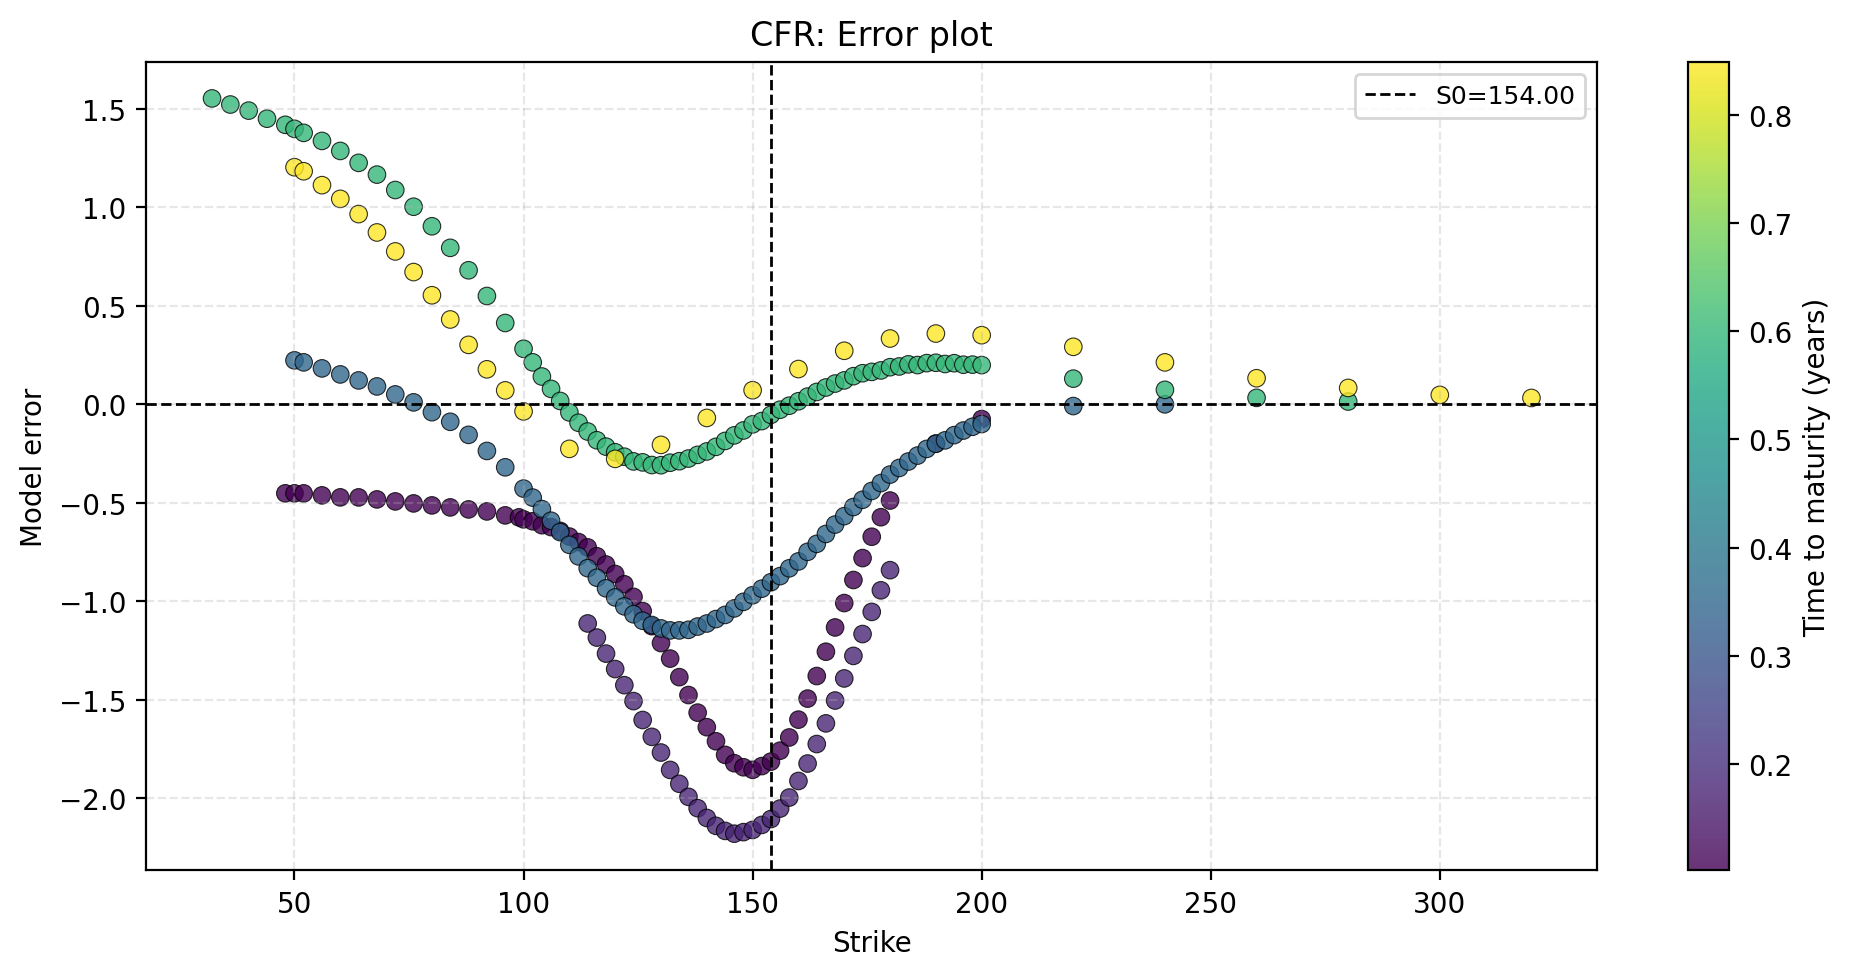

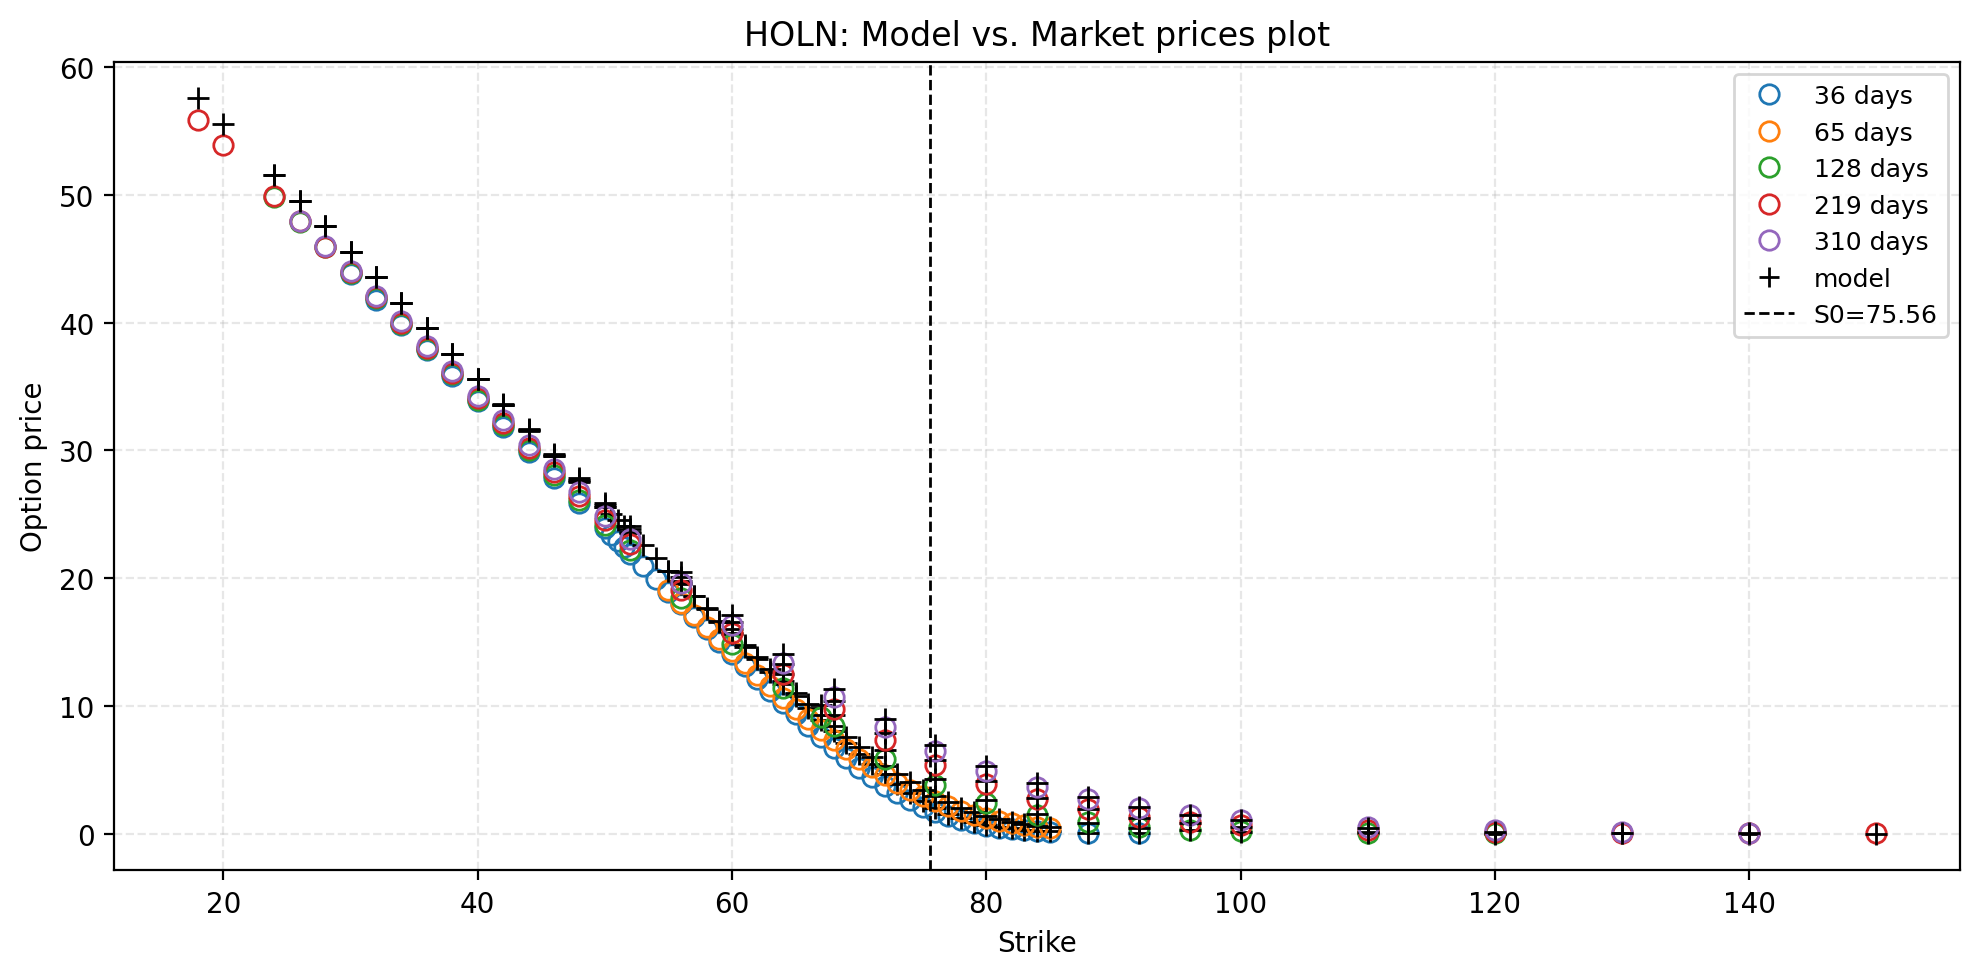

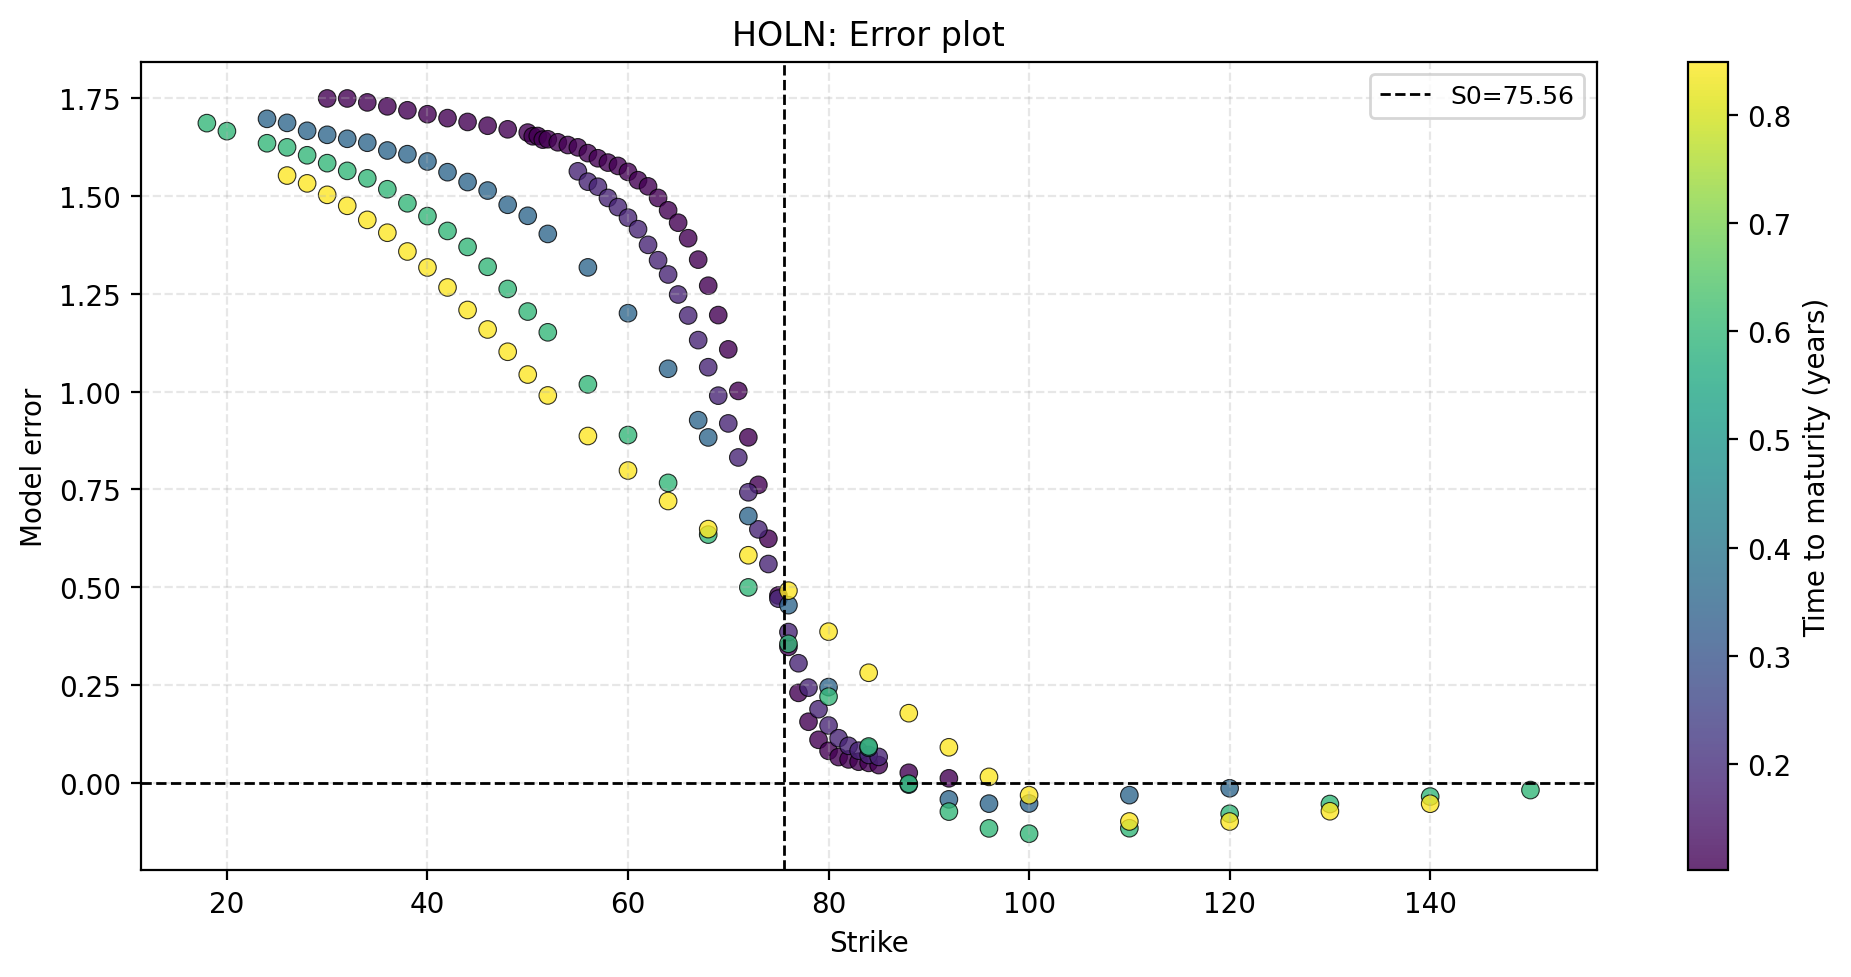

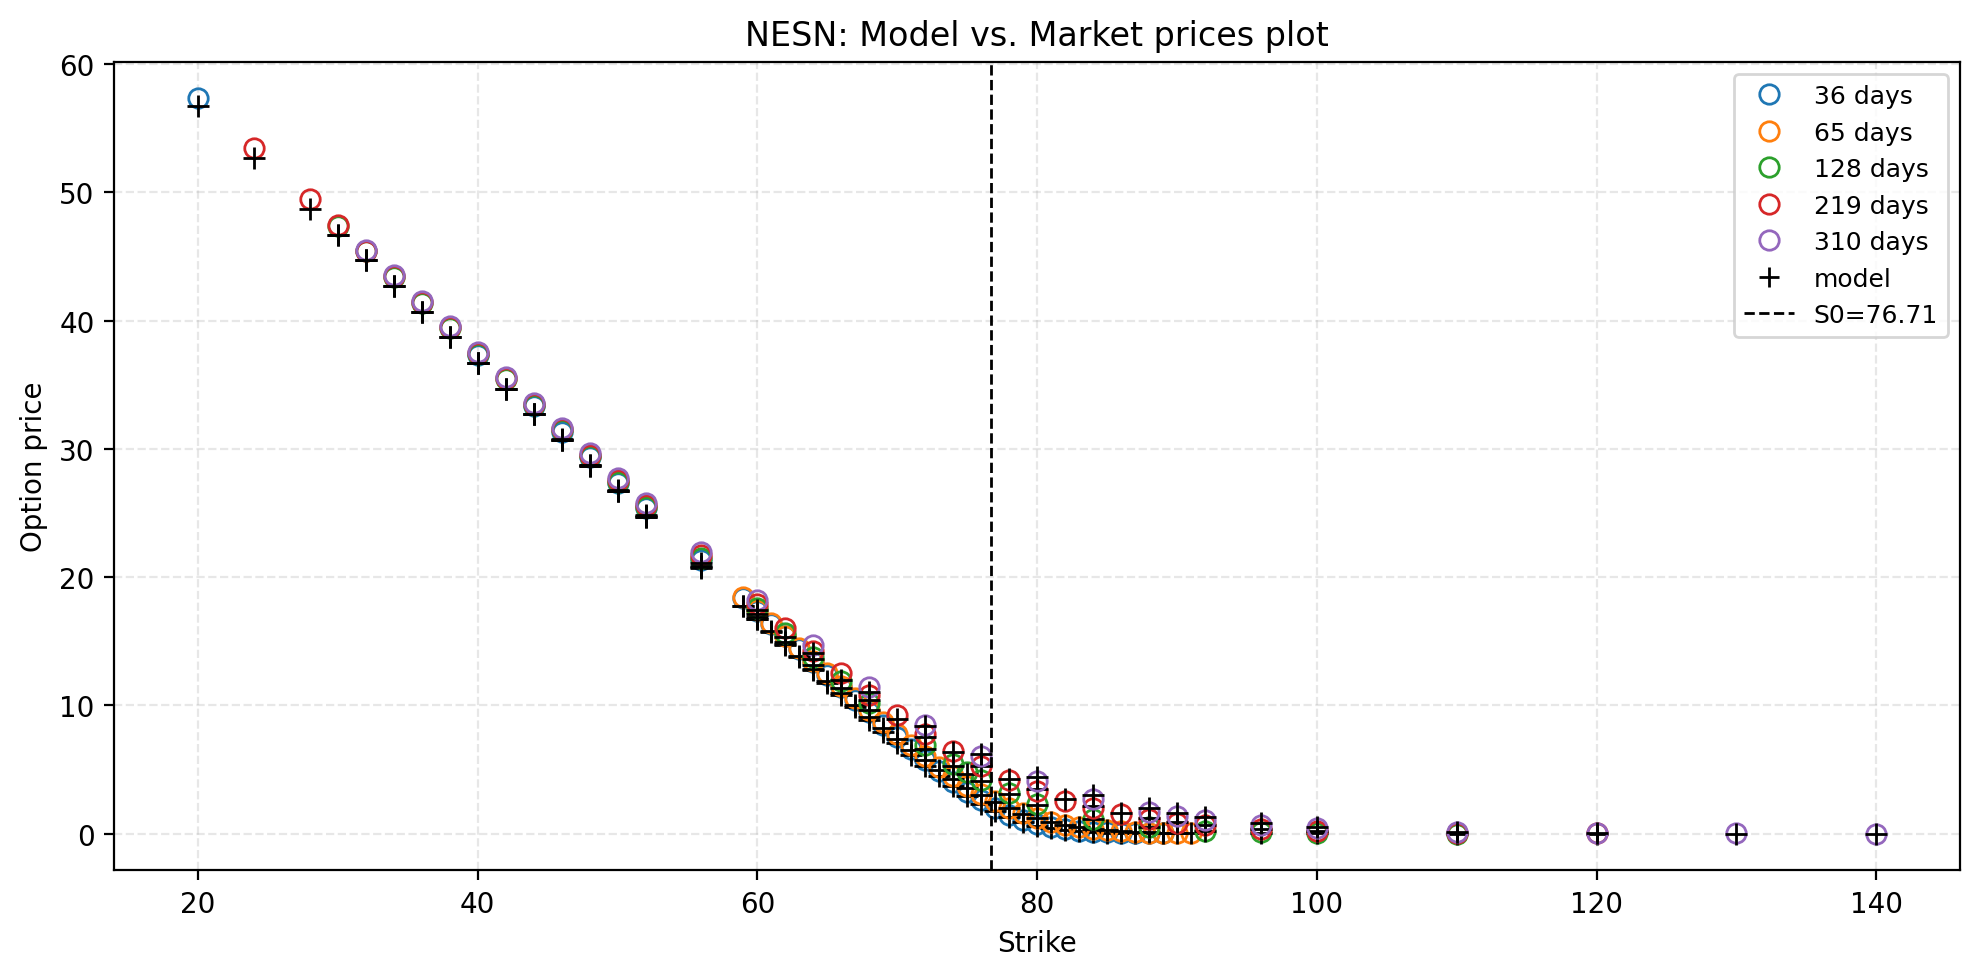

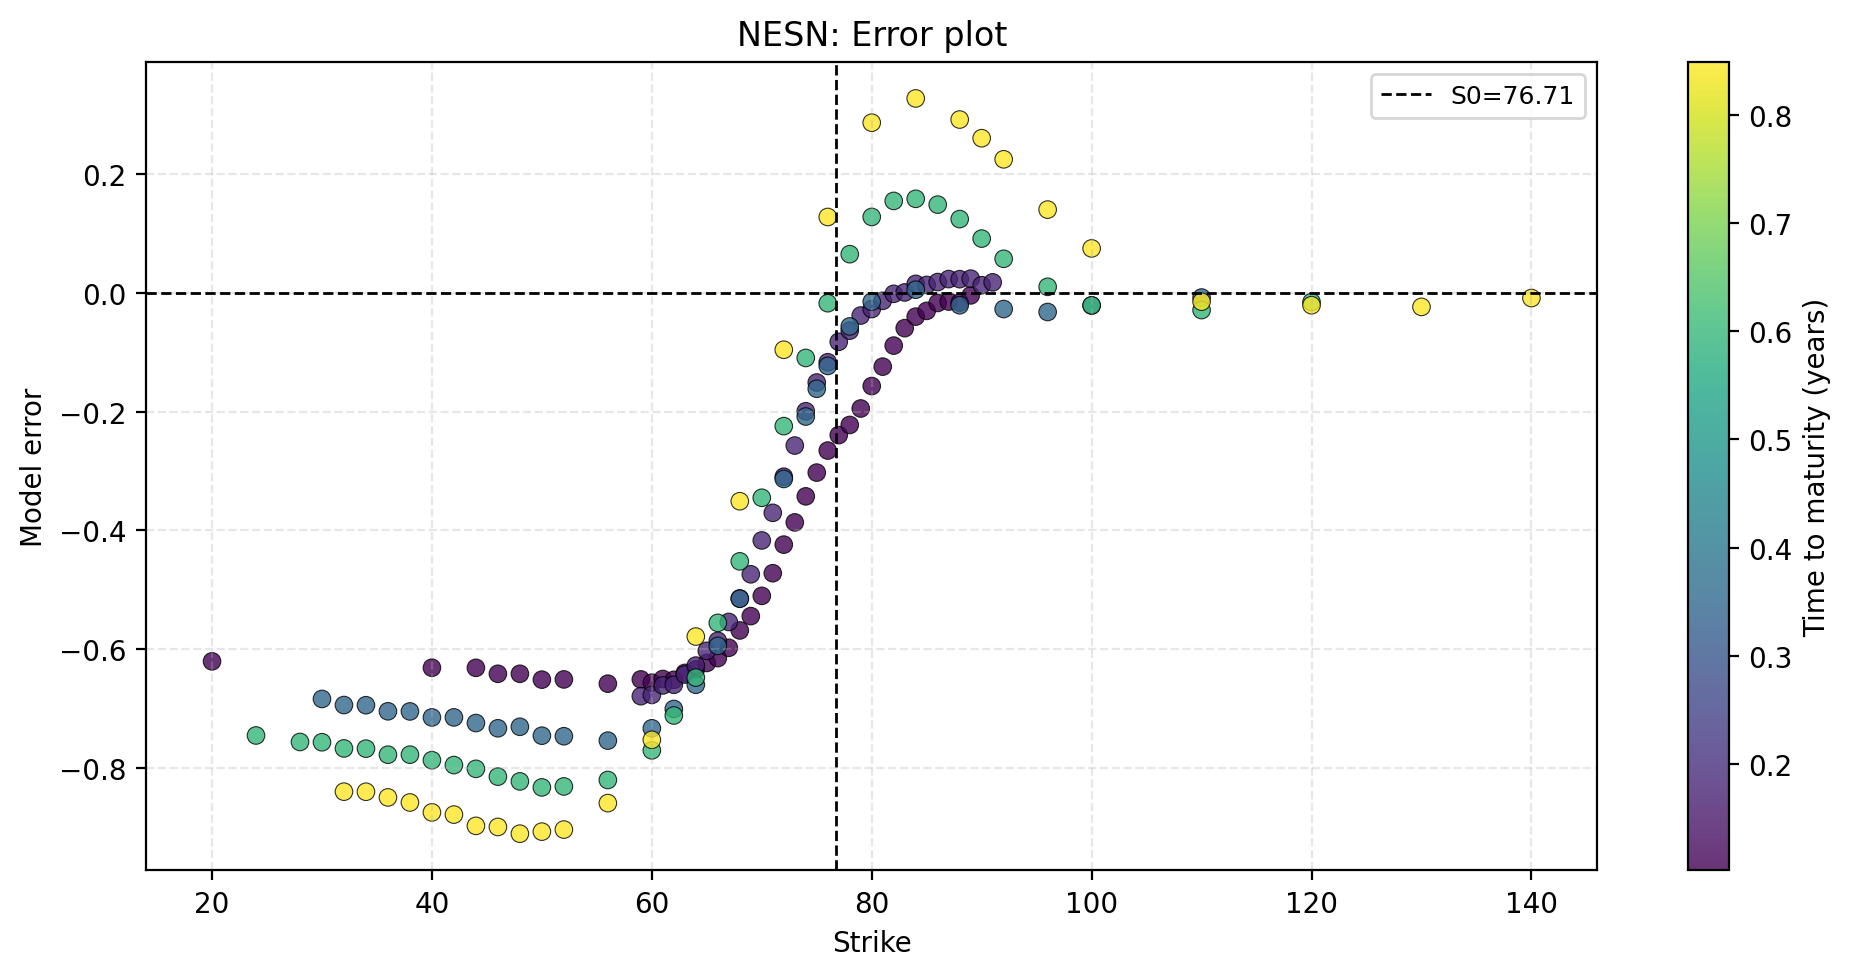

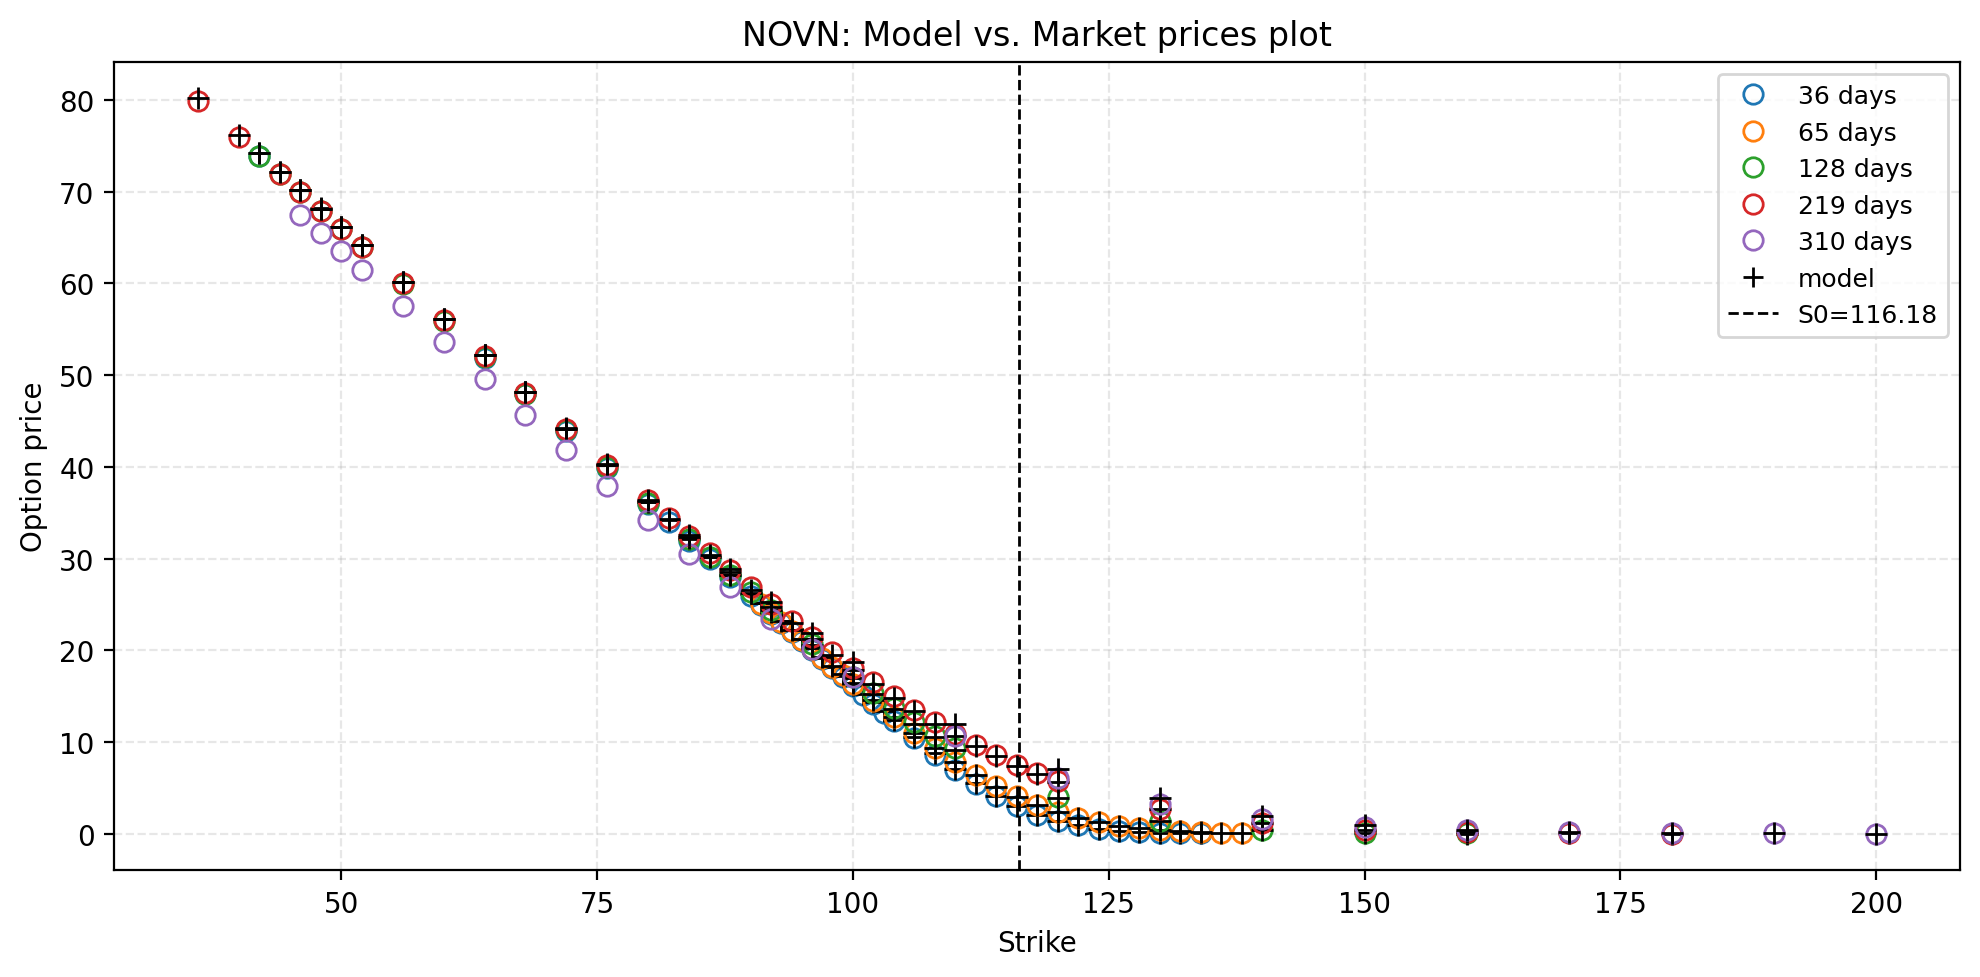

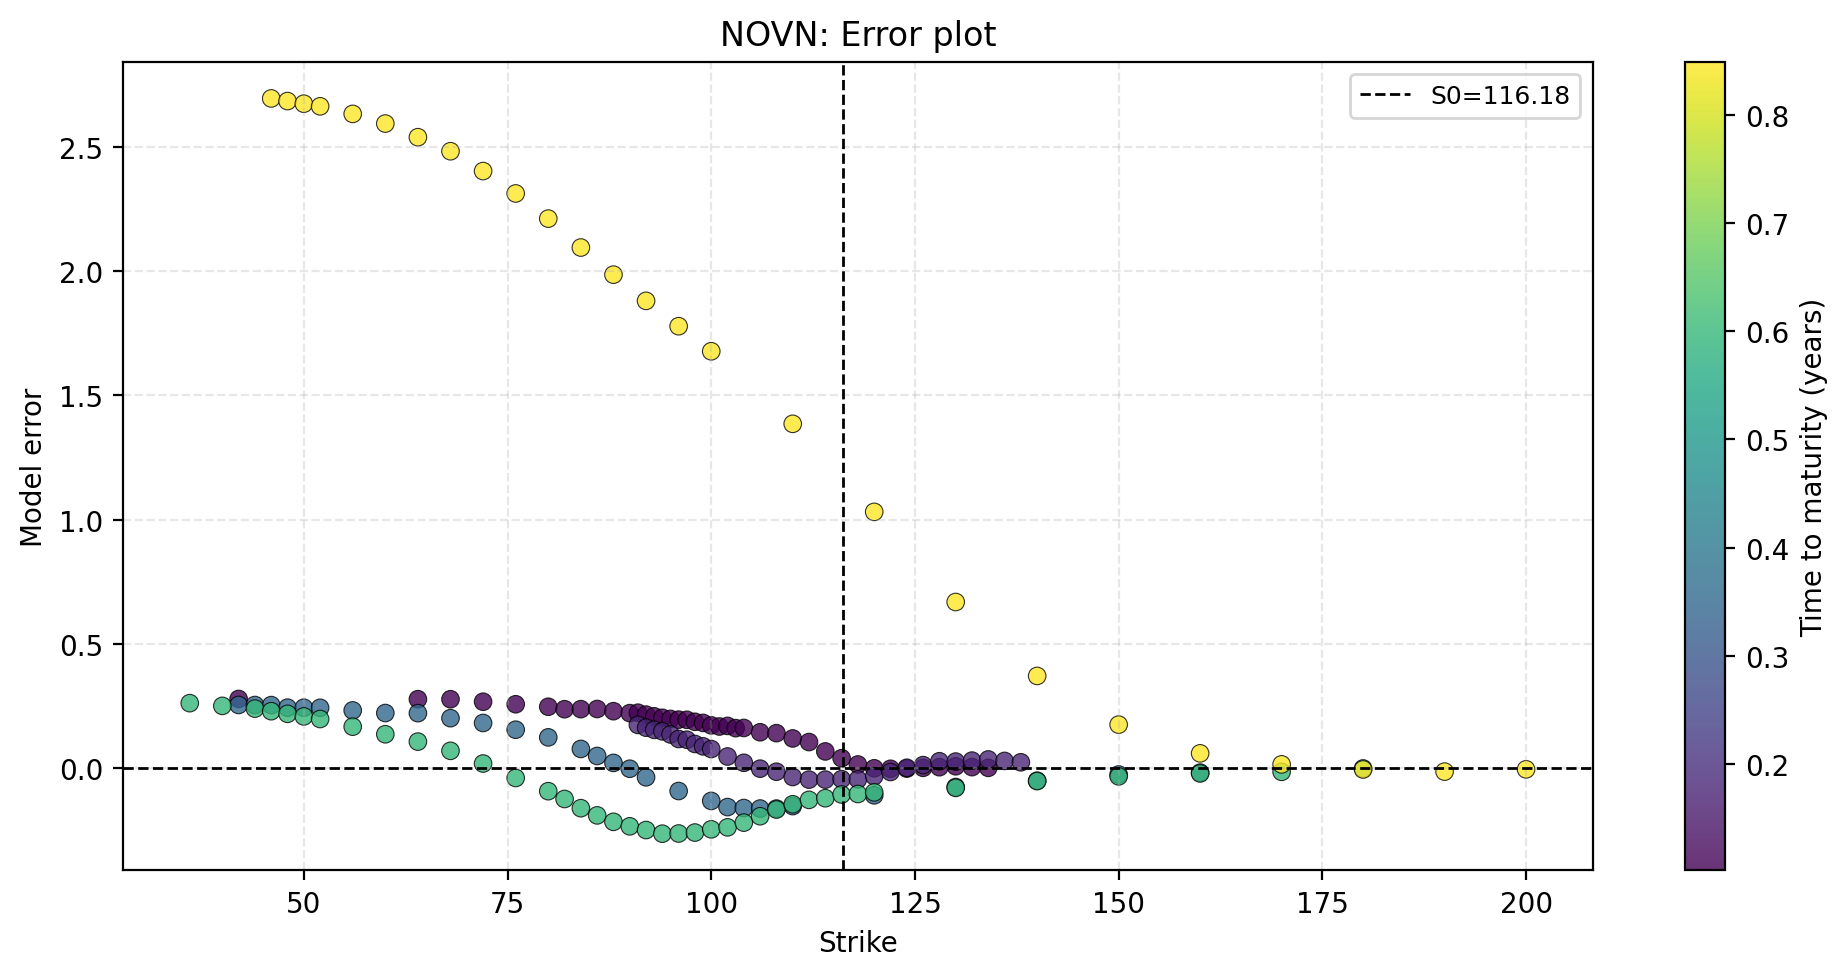

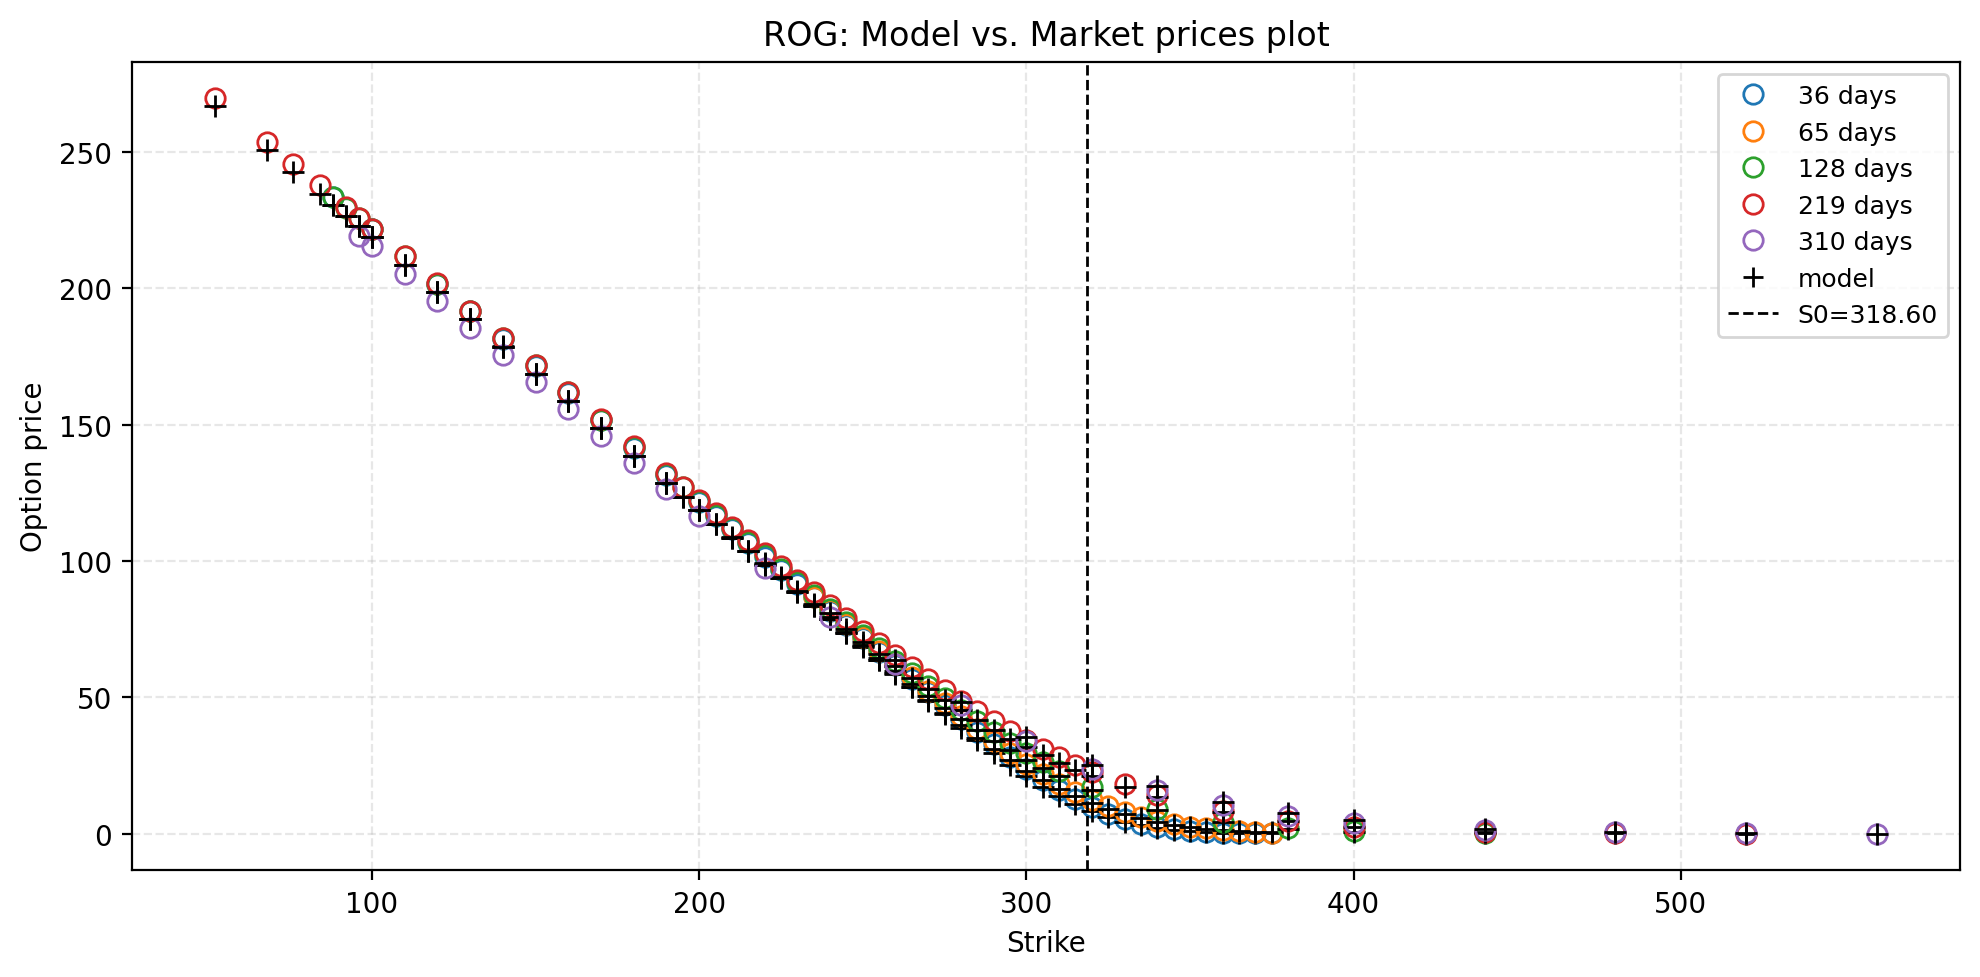

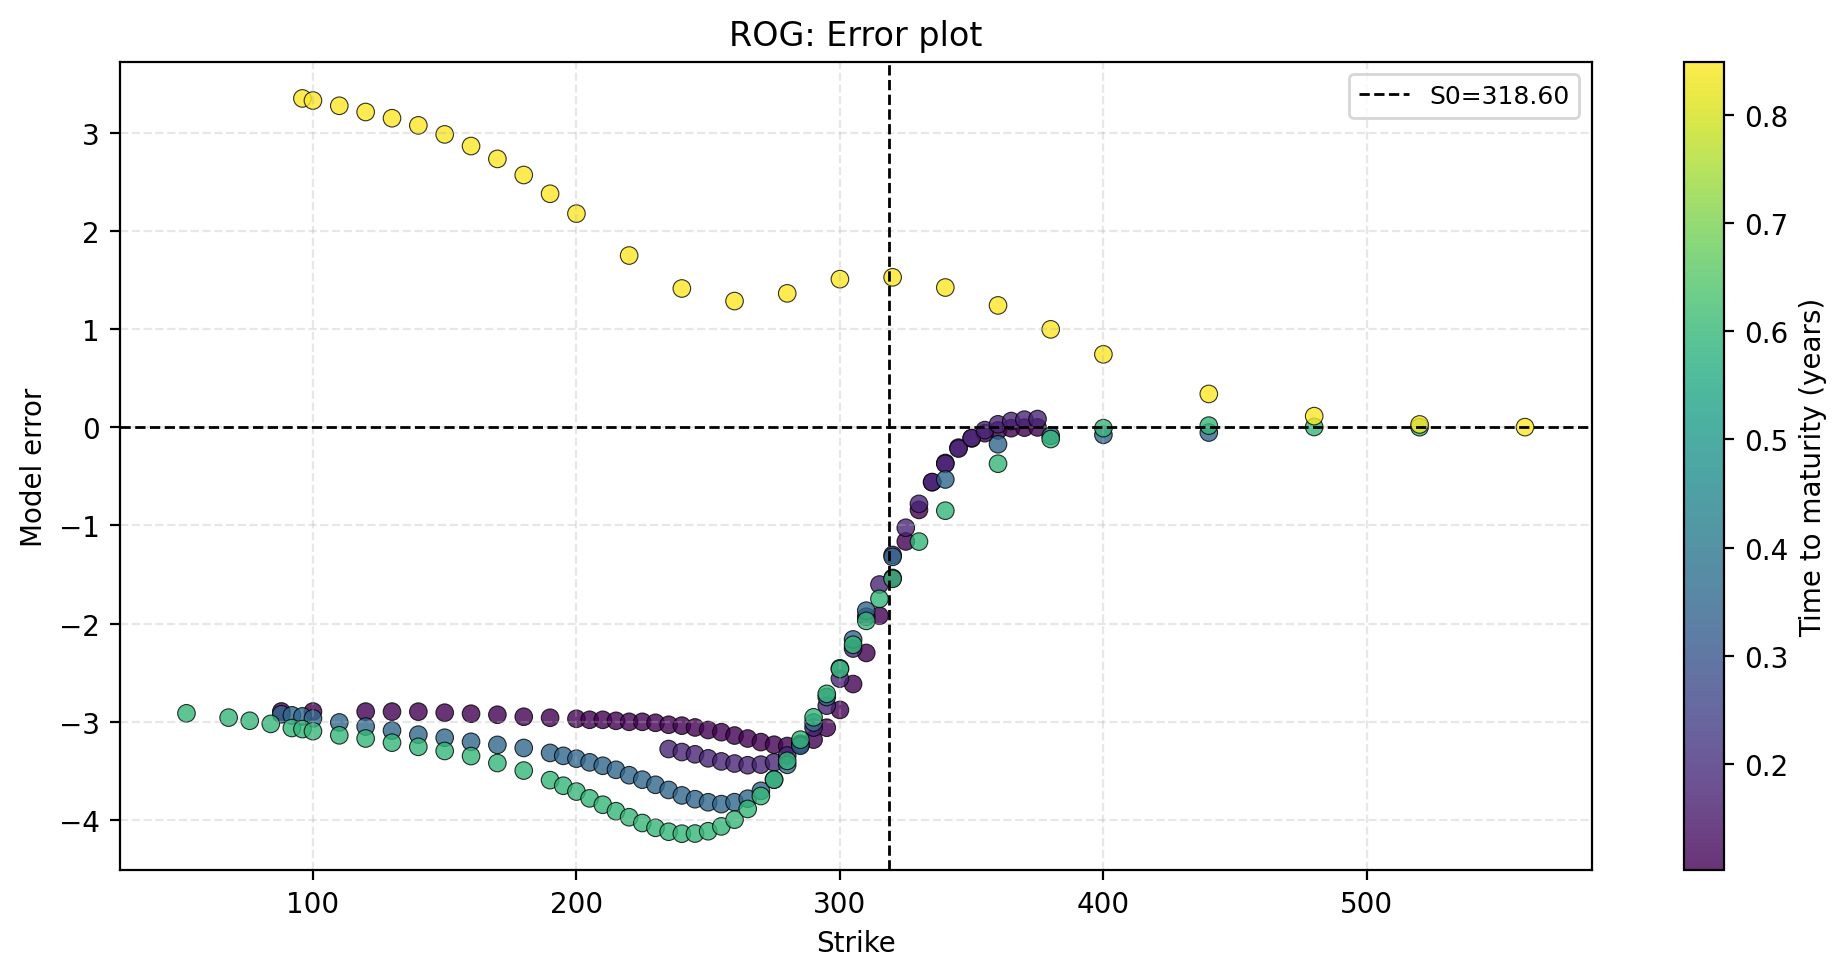

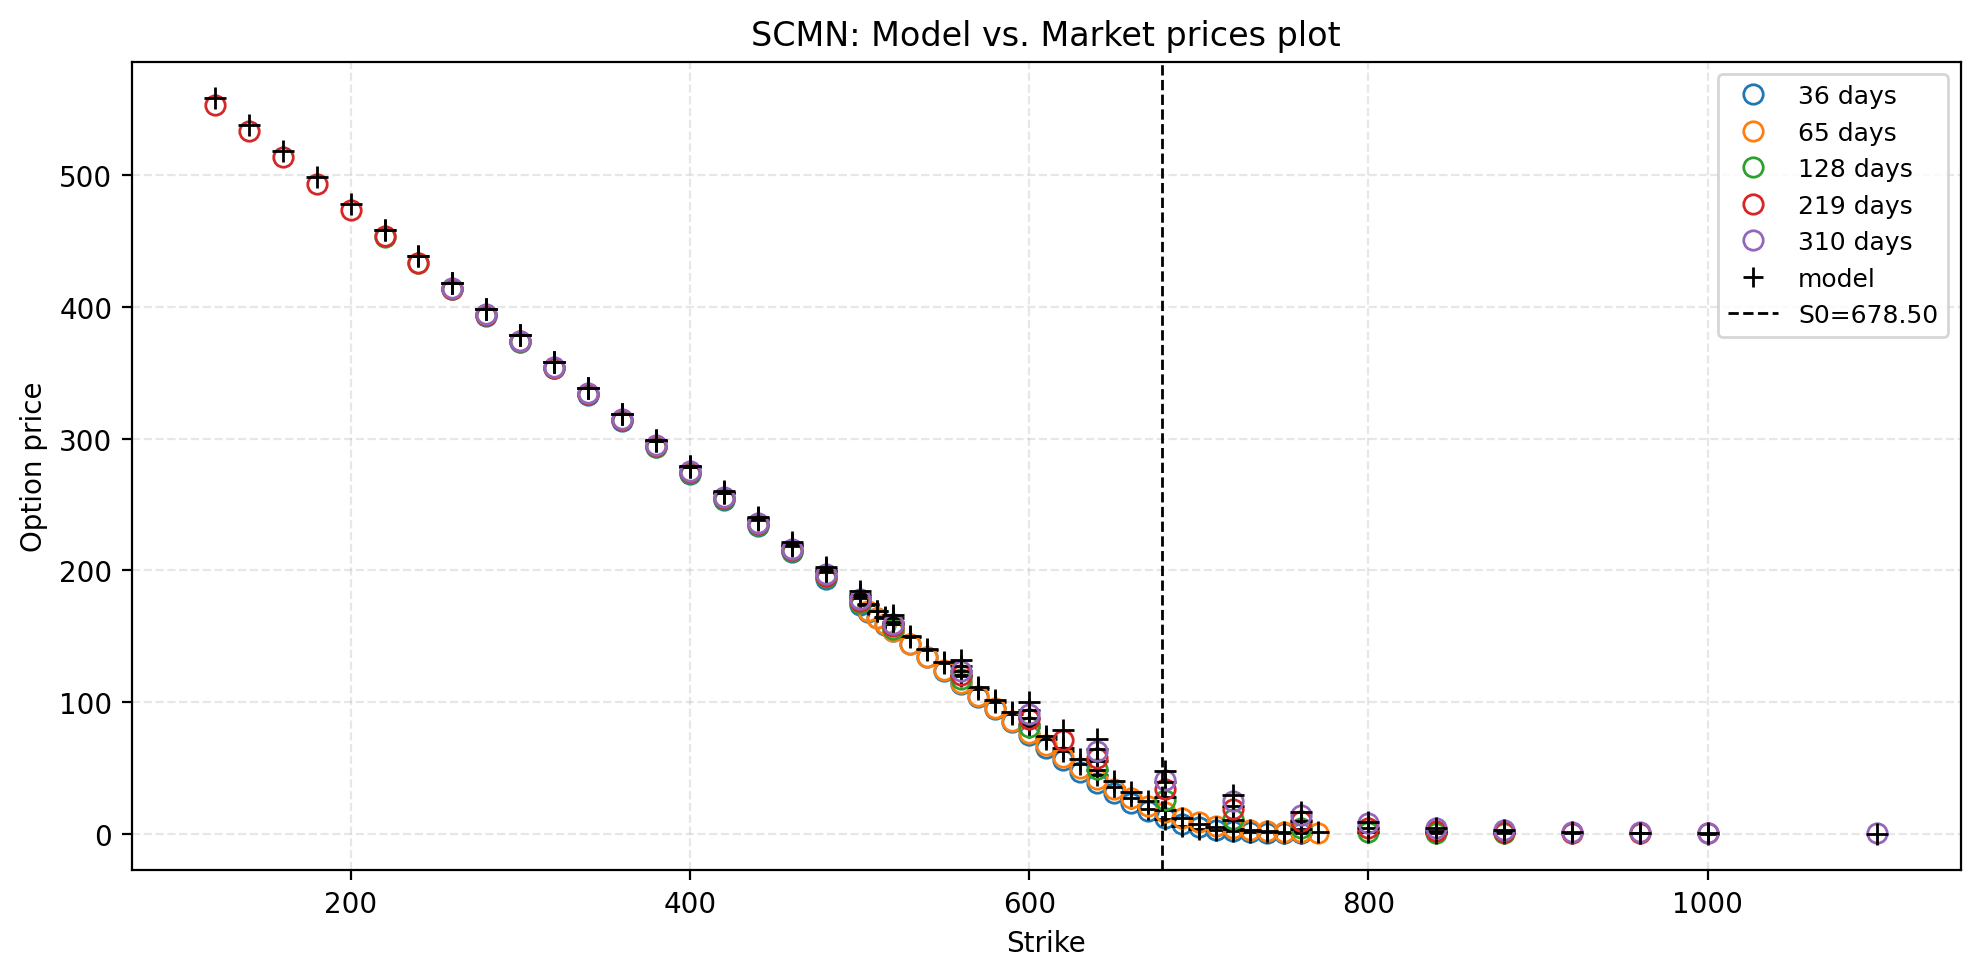

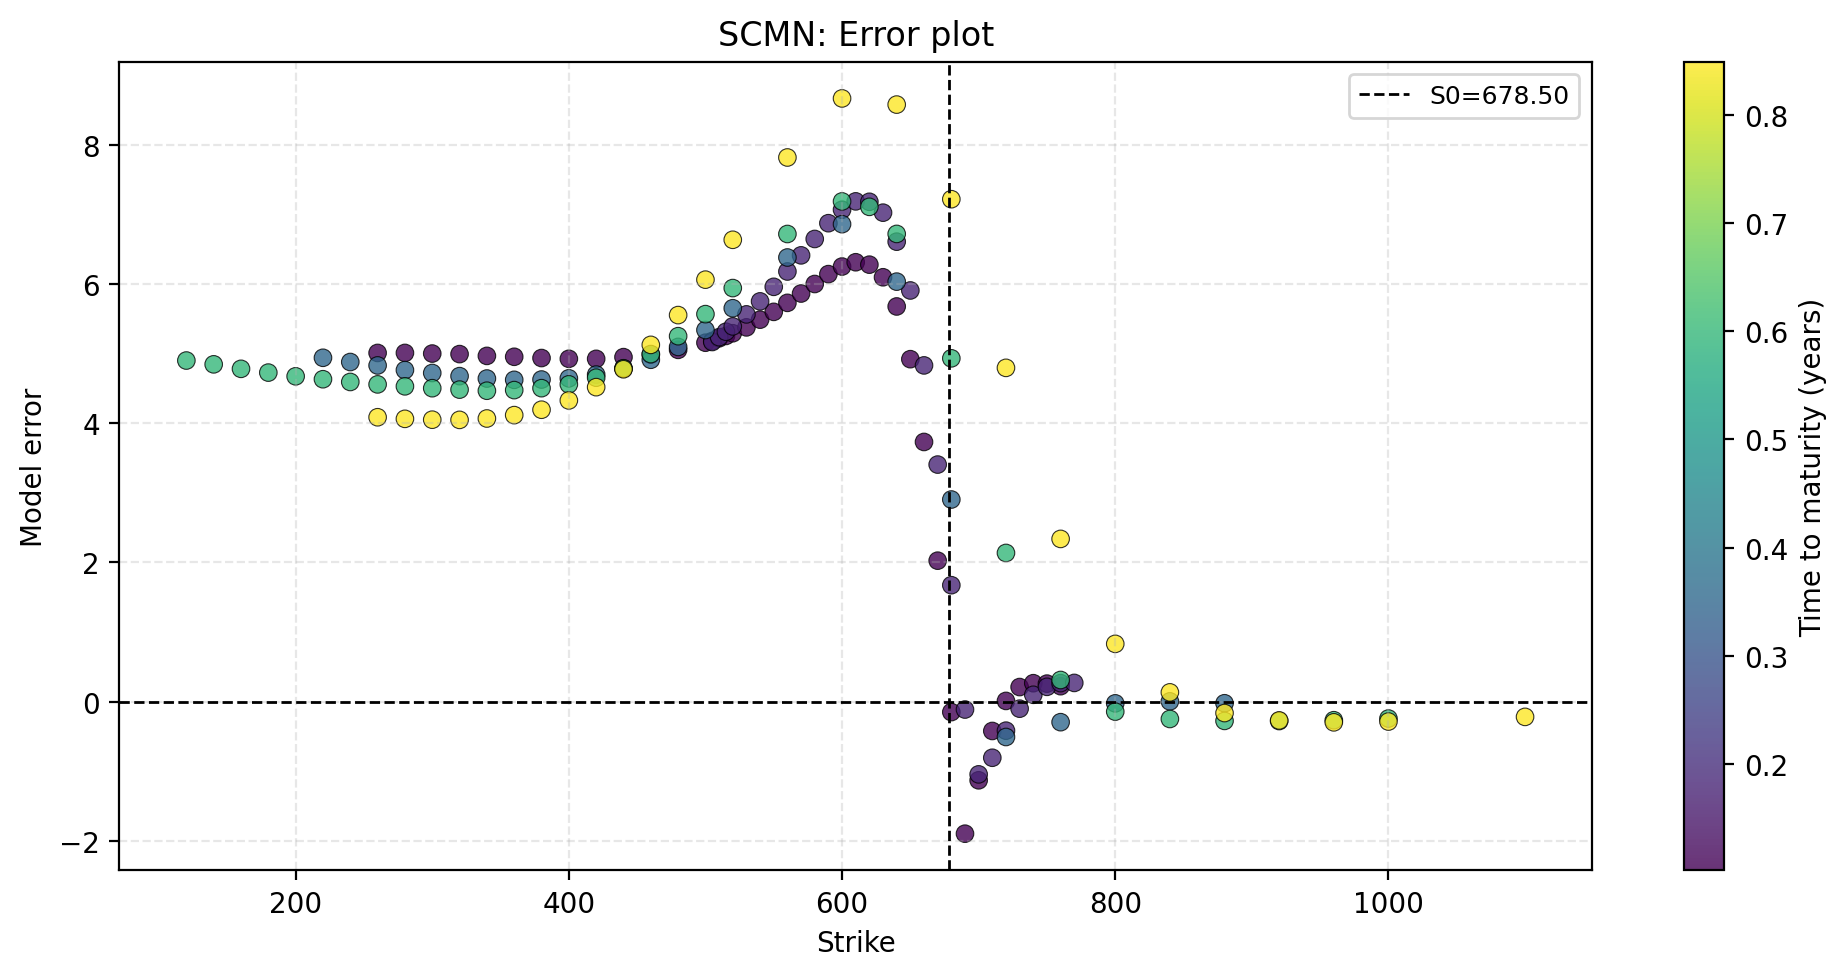

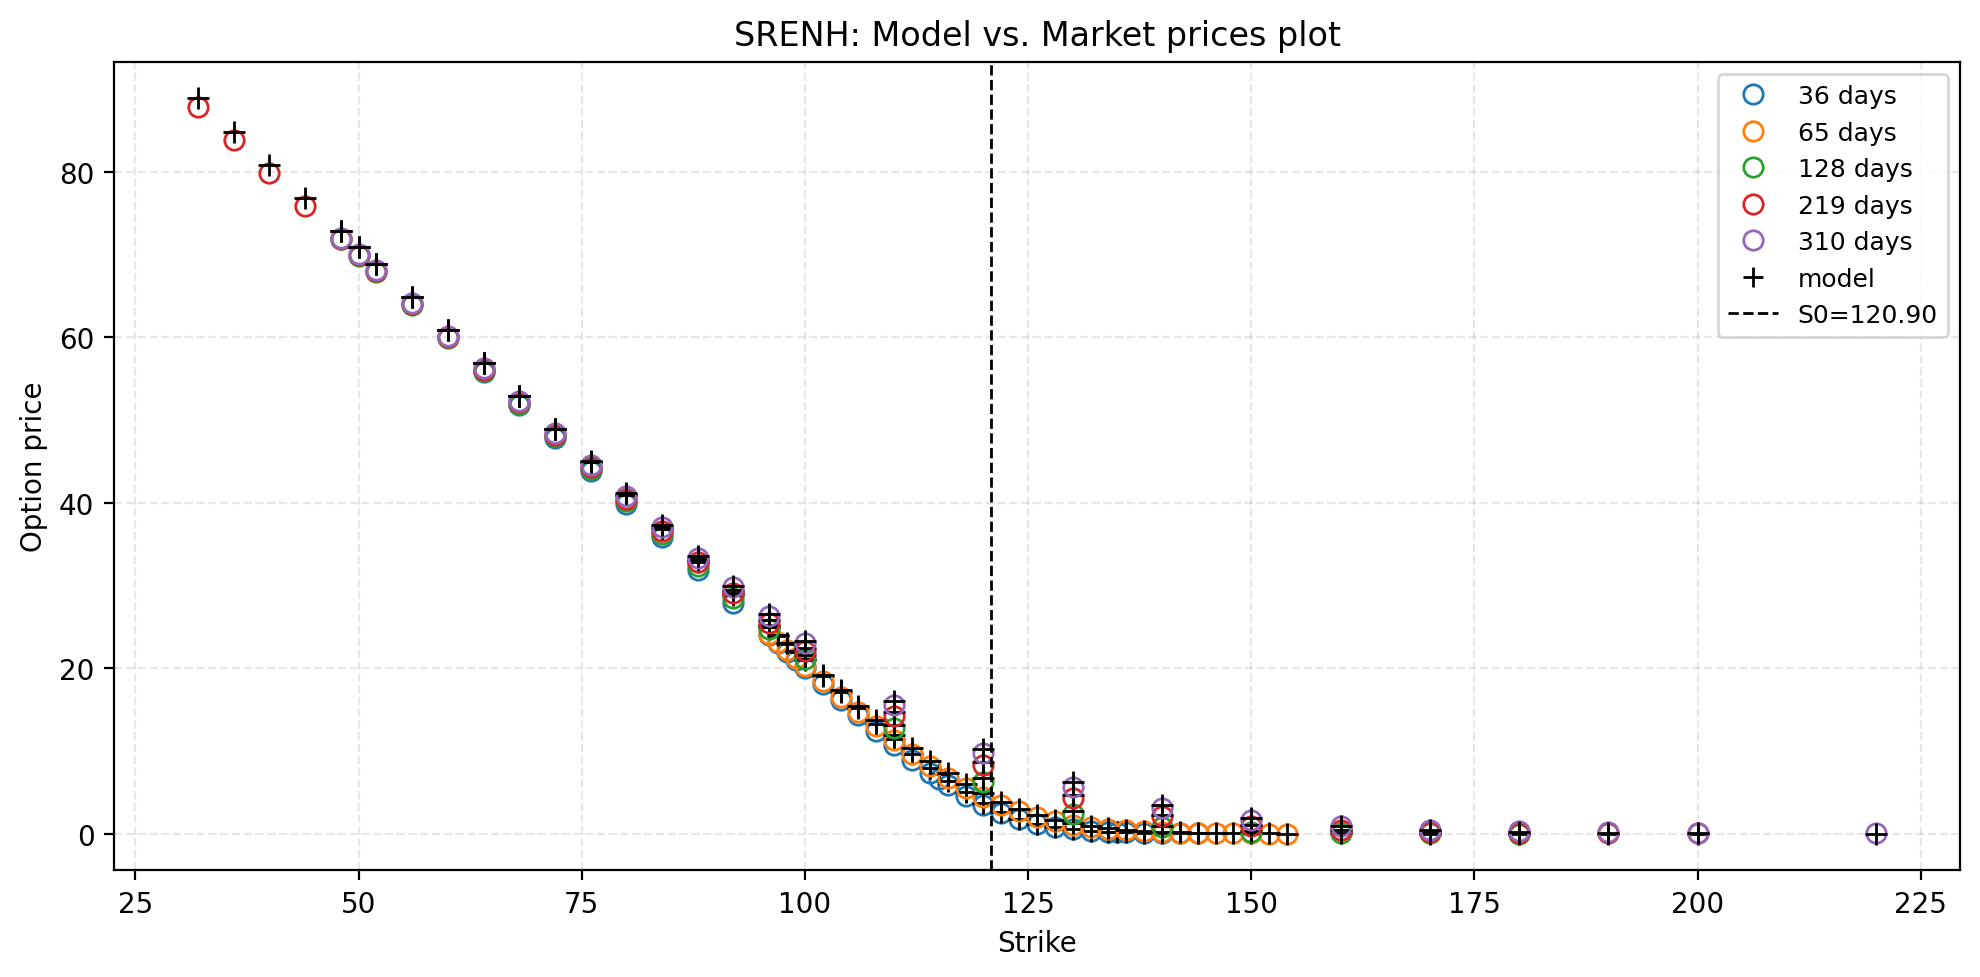

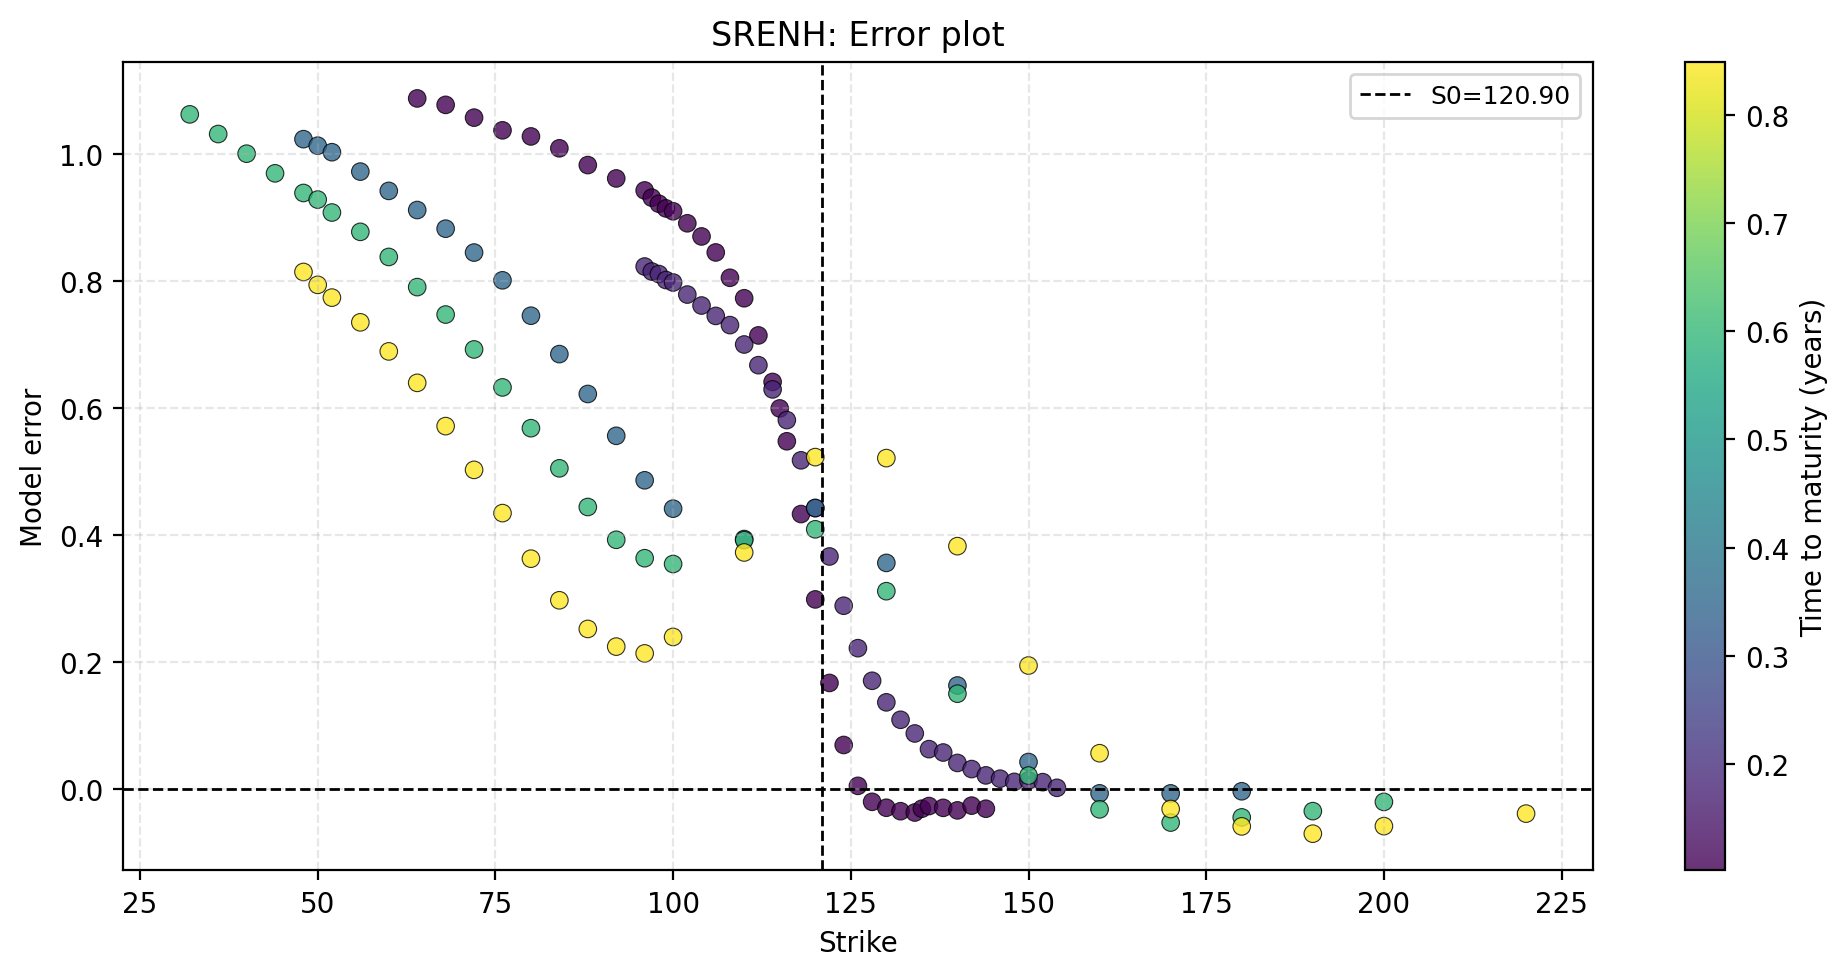

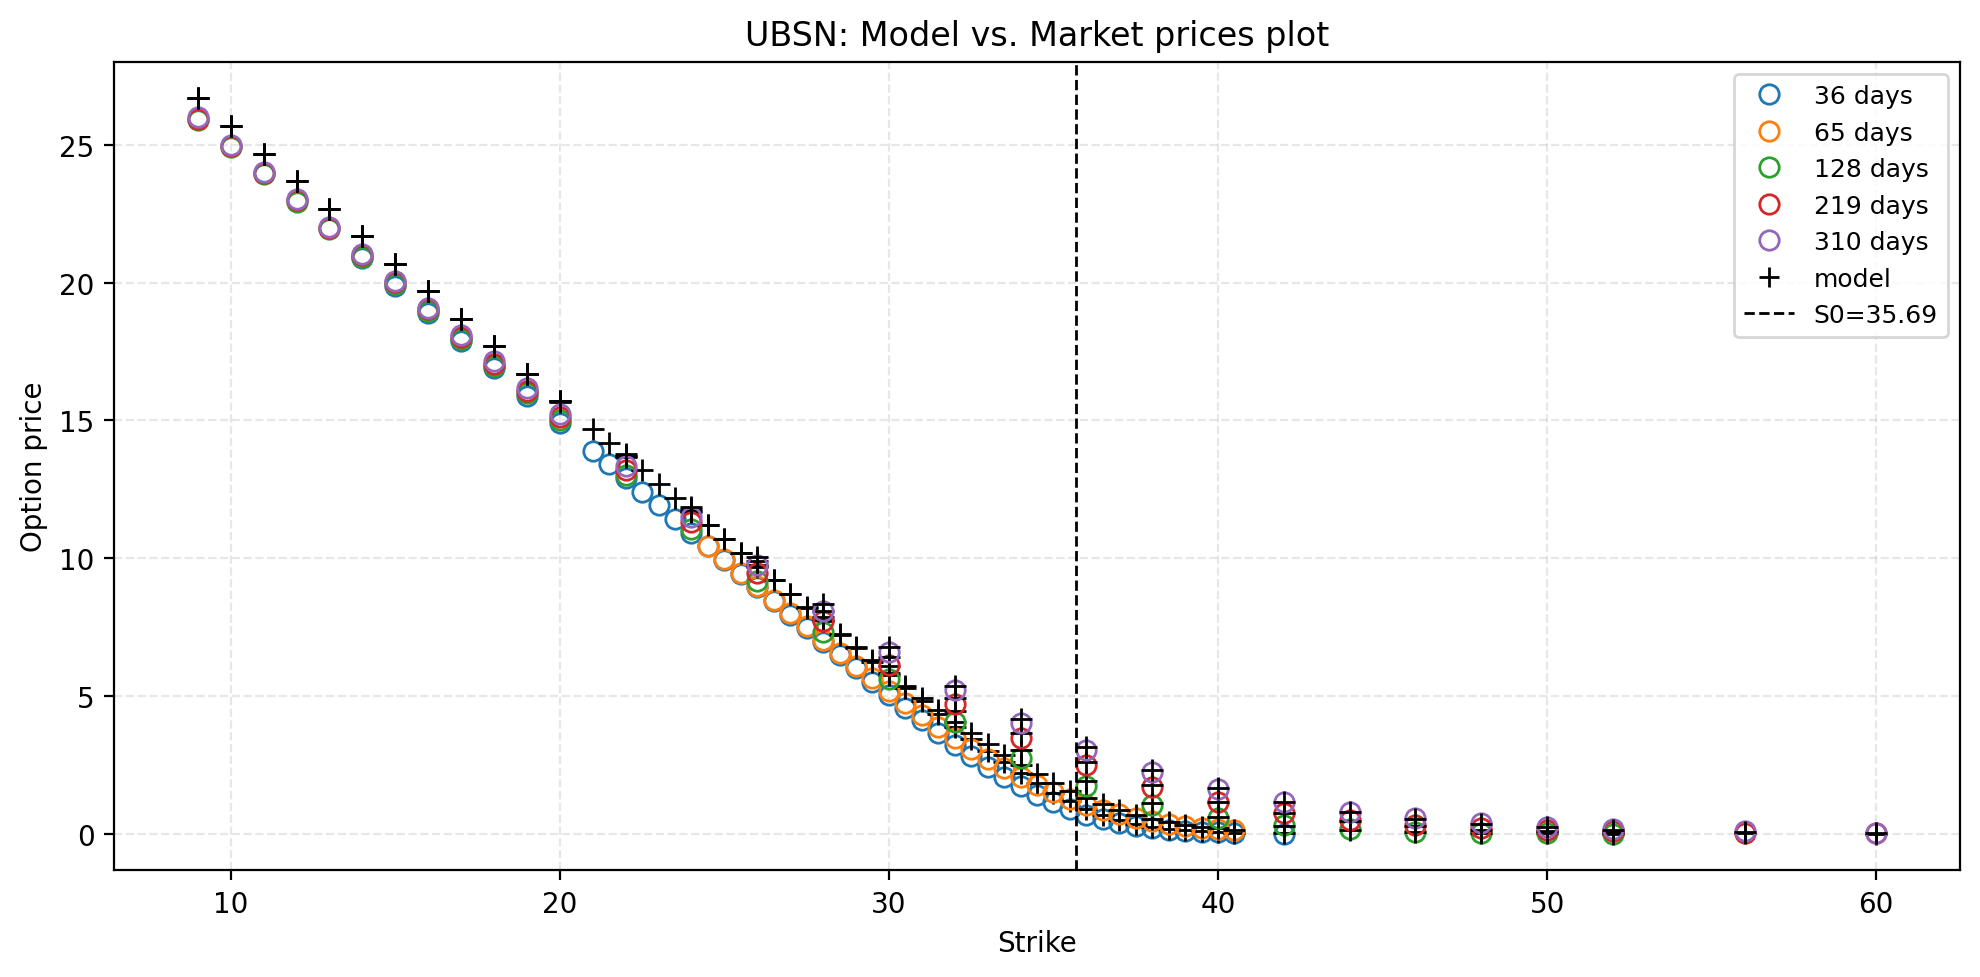

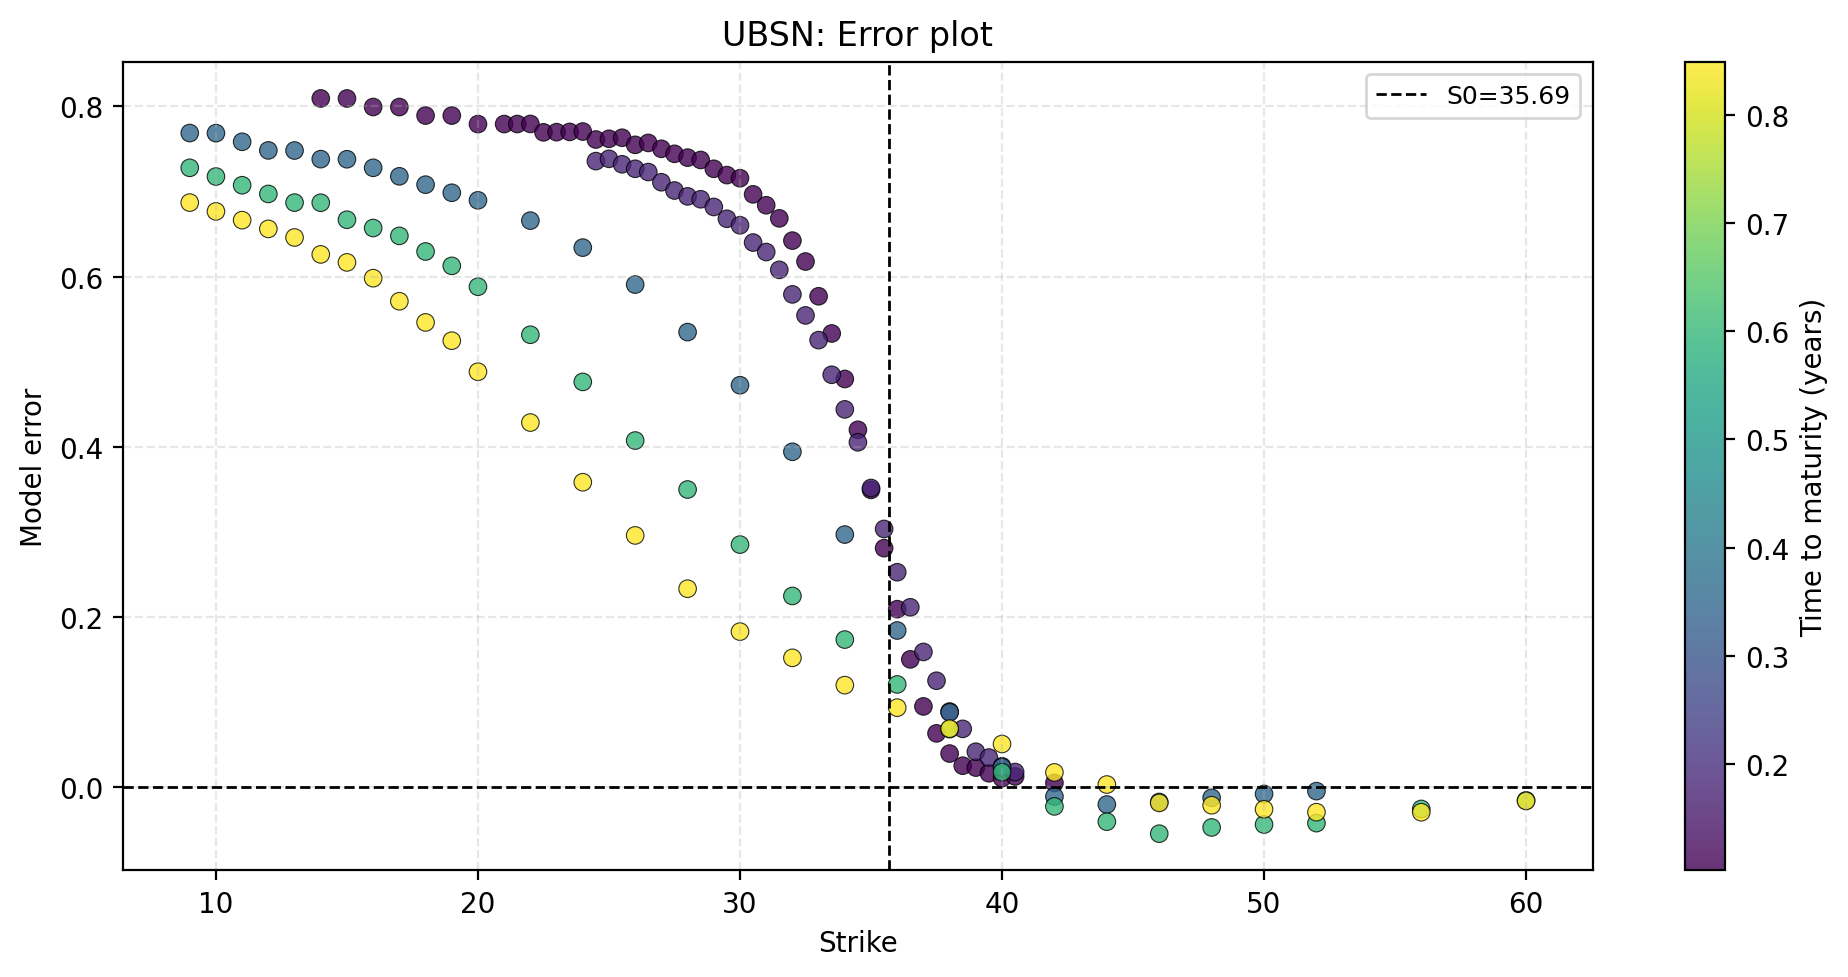

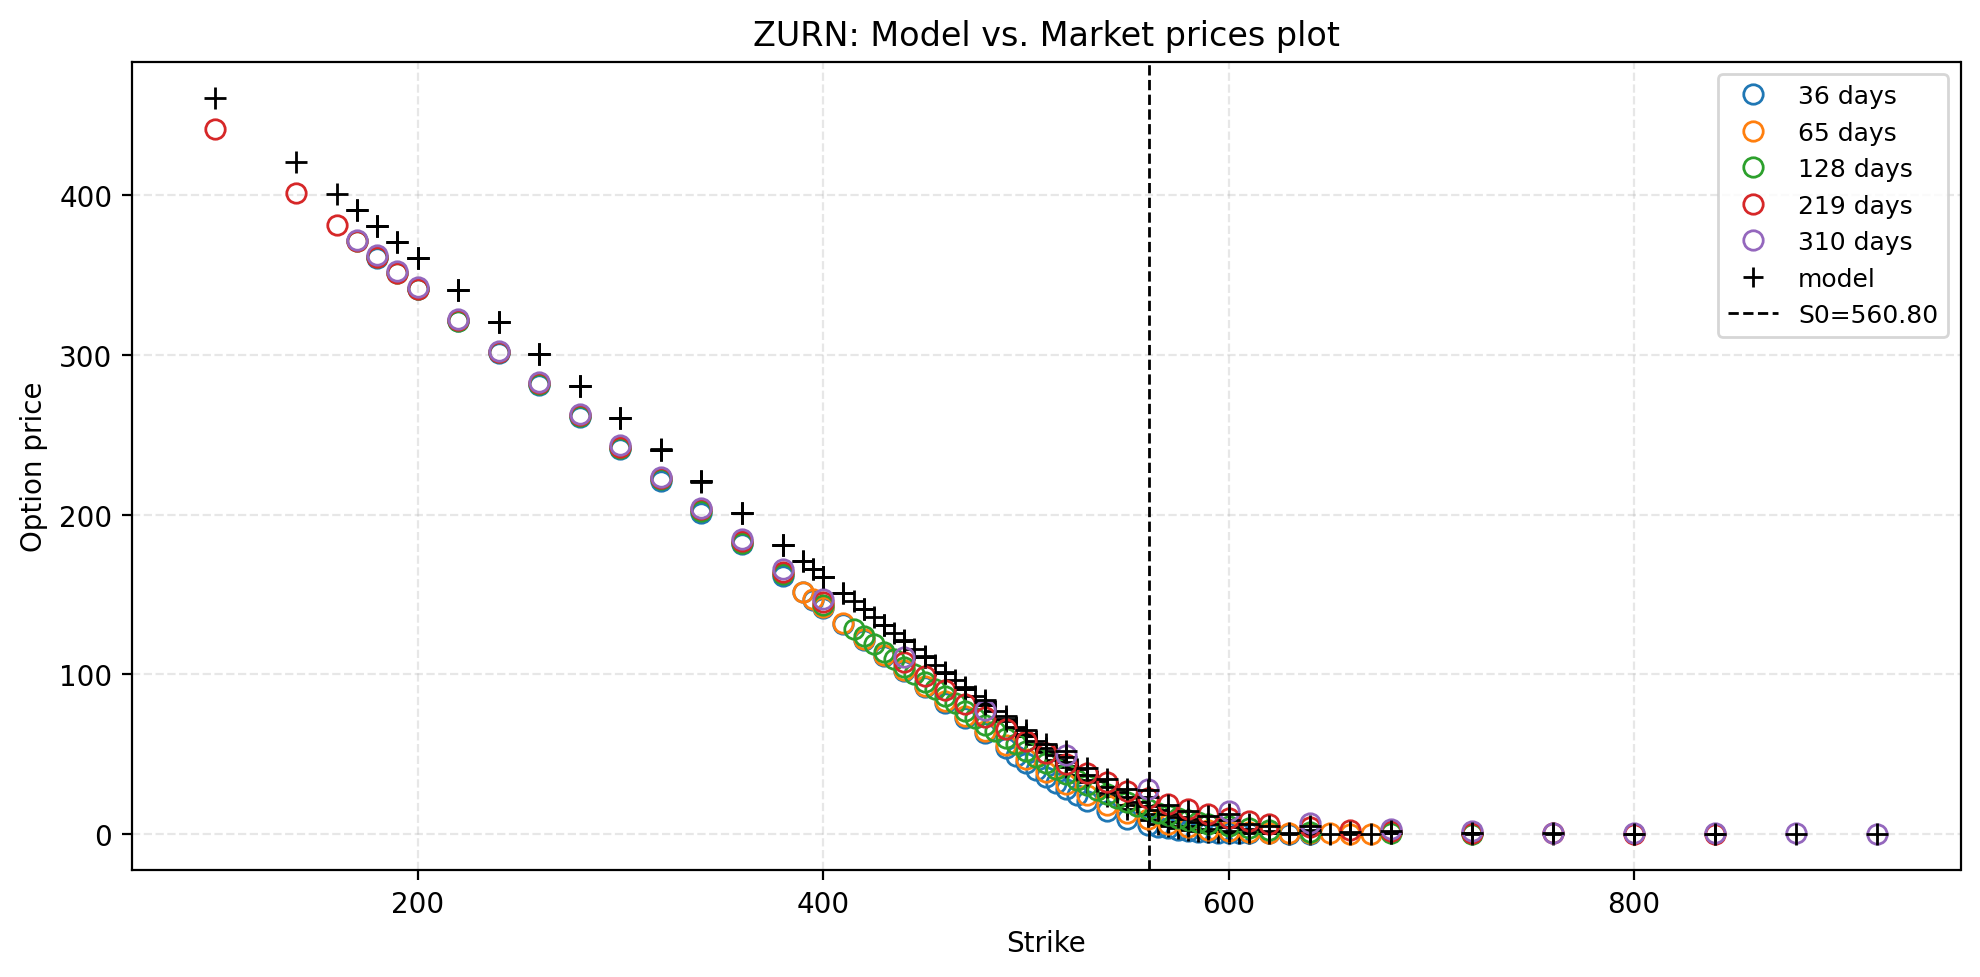

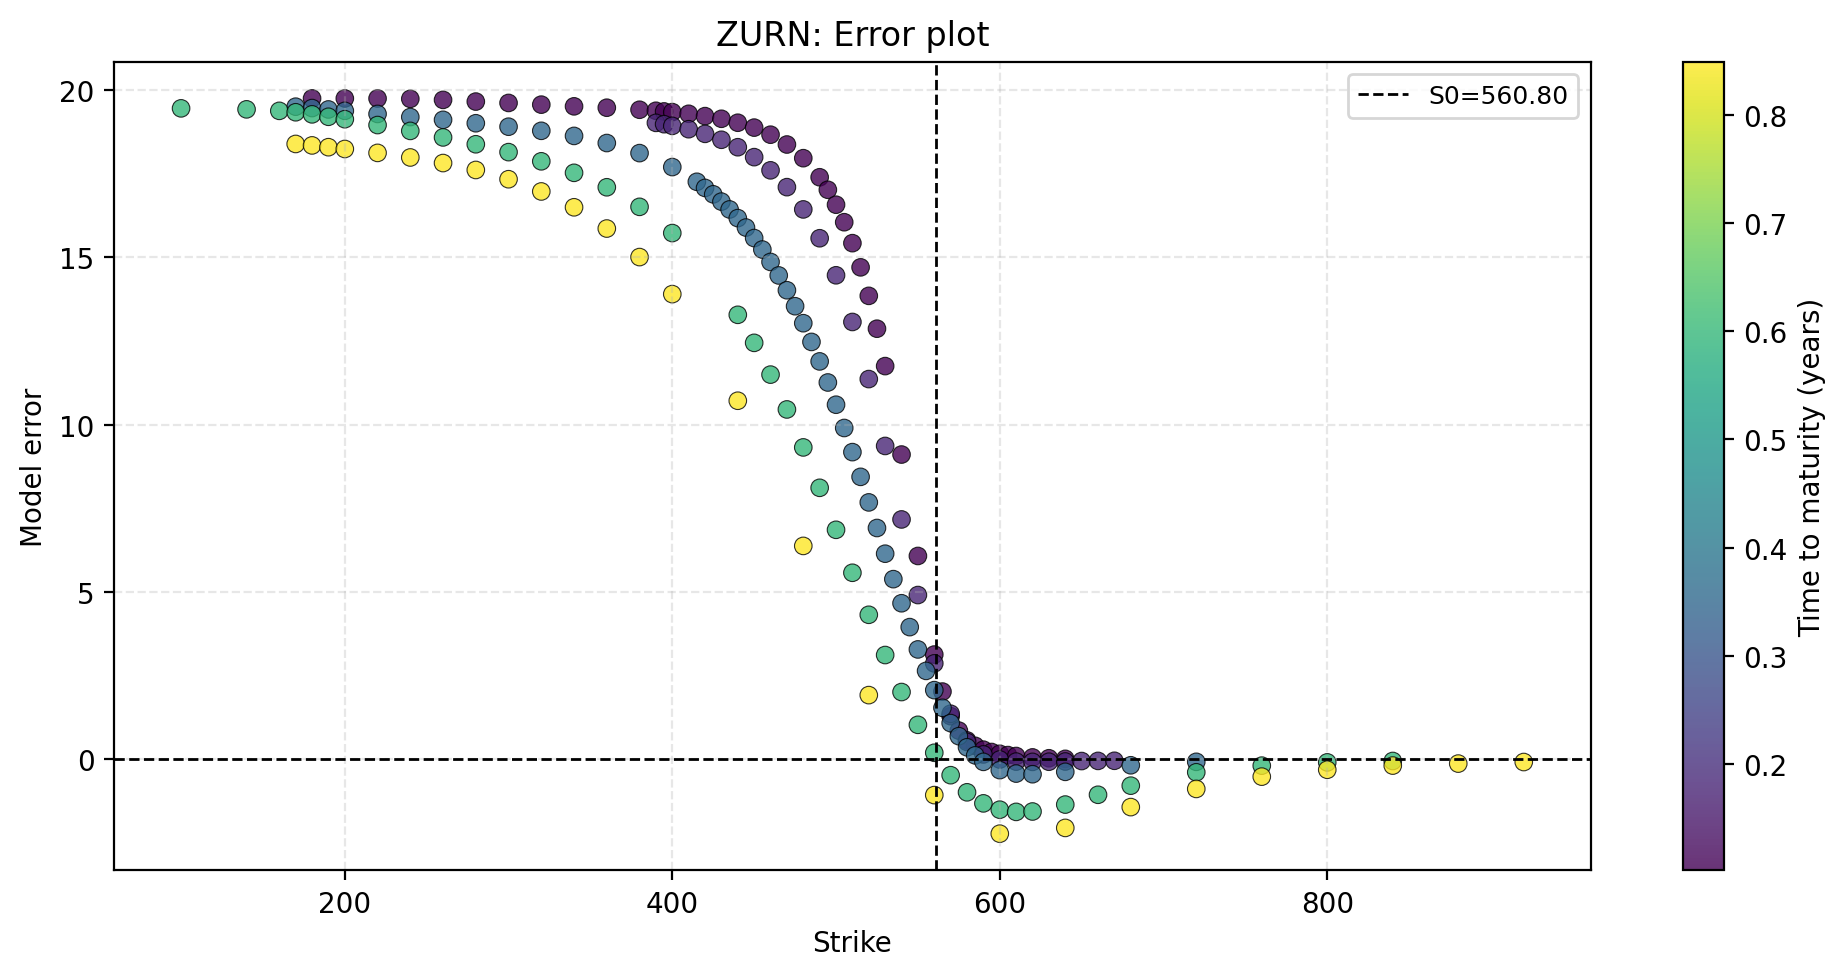

In [14]:
def plot_strike_slices(df, S0, price_col='FFT_price', plot_title='FFT calibration'):
    ttms = np.sort(df['time_to_maturity_years'].dropna().unique())
    ttm_days = (ttms * 365).astype(int)

    cmap = plt.get_cmap('tab10')
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

    for i, (tau, tau_days) in enumerate(zip(ttms, ttm_days)):
        sub = df[np.isclose(df['time_to_maturity_years'], tau, atol=1e-10, rtol=0.0)].sort_values('strike')
        color = cmap(i % 10)

        ax.plot(sub['strike'], sub['price'], marker='o', linestyle='none', markersize=7, markerfacecolor='none', markeredgecolor=color, label=f'{tau_days} days')
        ax.plot(sub['strike'], sub[price_col], marker='+', linestyle='none', markersize=8, color='k', label='_nolegend_')

    ax.plot([], [], marker='+', linestyle='none', color='k', markersize=7, label='model')
    ax.axvline(x=S0, linestyle='--', linewidth=1, color='k', label=f'S0={S0:.2f}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Option price')
    ax.set_title(plot_title)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_residuals_vs_strike(df, S0, error_col='FFT_error', plot_title='FFT residuals'):
    fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    sc = ax.scatter(df['strike'], df[error_col], c=df['time_to_maturity_years'], s=40, alpha=0.8, marker='o', edgecolors='k', linewidths=0.4)

    ax.axhline(0.0, color='k', linestyle='--', lw=1)
    ax.axvline(x=S0, linestyle='--', linewidth=1, color='k', label=f'S0={S0:.2f}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Model error')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(plot_title)
    ax.legend(loc='best', fontsize=9)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Time to maturity (years)')
    fig.tight_layout()
    plt.show()


PLOT_RESULTS = True

if PLOT_RESULTS:
    for i, ticker in enumerate(tickers):
        plot_strike_slices(dfs[i], stock_prices[i], plot_title=f'{ticker}: Model vs. Market prices plot')
        plot_residuals_vs_strike(dfs[i], stock_prices[i], plot_title=f'{ticker}: Error plot')


## 3. Computing correlation and drift terms using stocks data

In [15]:
stock_price_dfs = []

for ticker, path in filepaths_stocks_and_dividends.items():
    df_stock = pd.read_excel(path, sheet_name='Stock Data')

    df_stock = df_stock.rename(columns={'TRDPRC_1': ticker})
    df_stock['Date'] = pd.to_datetime(df_stock['Date'])

    df_stock = df_stock[['Date', ticker]]
    df_stock = df_stock.set_index('Date').sort_index()

    stock_price_dfs.append(df_stock)

stocks_df = pd.concat(stock_price_dfs, axis=1, join='inner').sort_index()
stocks_df = stocks_df[tickers]
stocks_df.head()

,ABB,CFR,HOLN,NESN,NOVN,ROG,SCMN,SRENH,UBSN,ZURN
Date,,,,,,,,,,
2024-05-14,47.56,136.40,39.825897,94.64,93.49,224.6,502.0,103.40,27.33,452.5
2024-05-15,48.20,136.55,40.334010,95.54,93.30,227.5,503.5,103.70,27.67,453.3
2024-05-16,47.65,137.45,39.856384,95.42,92.62,234.8,502.0,107.65,27.42,469.1
2024-05-17,47.41,144.75,39.876708,96.62,93.37,237.1,503.0,110.10,27.54,471.8
2024-05-21,48.46,143.55,39.785248,95.30,93.89,234.4,499.2,110.30,27.70,472.8


In [16]:
stocks_df.rename(columns={'ROPC': 'ROG', 'UBSG': 'UBSN'}, inplace=True)
stocks_df.tail()

,ABB,CFR,HOLN,NESN,NOVN,ROG,SCMN,SRENH,UBSN,ZURN
Date,,,,,,,,,,
2026-05-06,82.40,155.75,74.10,78.61,115.64,321.9,671.0,128.40,35.25,550.4
2026-05-07,81.22,158.60,74.10,77.48,113.30,318.3,669.0,124.30,34.94,544.6
2026-05-08,82.02,158.40,74.30,77.47,113.36,315.3,669.5,123.45,35.03,540.4
2026-05-11,83.56,154.30,75.22,76.10,113.70,319.4,671.0,124.10,35.04,546.4
2026-05-12,81.16,154.45,75.40,77.32,115.90,321.5,673.5,119.80,34.87,541.0


### 3.1 Correlation matrix

In [17]:
log_returns = np.log(stocks_df).diff().dropna()

log_returns_corr_matrix = log_returns.corr()
log_returns_corr_matrix

,ABB,CFR,HOLN,NESN,NOVN,ROG,SCMN,SRENH,UBSN,ZURN
ABB,1.000000,0.409036,0.538841,0.079450,0.215799,0.236806,0.020752,0.314673,0.552149,0.338236
CFR,0.409036,1.000000,0.355550,0.204492,0.221500,0.250789,0.018549,0.262957,0.414136,0.293323
HOLN,0.538841,0.355550,1.000000,0.102394,0.239365,0.243906,0.033054,0.317639,0.572992,0.326051
NESN,0.079450,0.204492,0.102394,1.000000,0.393913,0.339030,0.279350,0.231002,0.047569,0.268952
NOVN,0.215799,0.221500,0.239365,0.393913,1.000000,0.563557,0.350217,0.314854,0.211901,0.413535
ROG,0.236806,0.250789,0.243906,0.339030,0.563557,1.000000,0.242613,0.329942,0.243896,0.374916
SCMN,0.020752,0.018549,0.033054,0.279350,0.350217,0.242613,1.000000,0.264211,-0.013403,0.289033
SRENH,0.314673,0.262957,0.317639,0.231002,0.314854,0.329942,0.264211,1.000000,0.297076,0.667101
UBSN,0.552149,0.414136,0.572992,0.047569,0.211901,0.243896,-0.013403,0.297076,1.000000,0.355082
ZURN,0.338236,0.293323,0.326051,0.268952,0.413535,0.374916,0.289033,0.667101,0.355082,1.000000


### 3.2 Computing the drift

In [18]:
dt = 1/252

# Uncapped annualized historical log-return
annual_log_return = log_returns.mean()/dt

# 95% right-tail capped annualized historical log-return
r_cap_95 = log_returns.quantile(0.95)
log_returns_cap95 = log_returns.clip(upper=r_cap_95, axis=1)
annual_log_return_cap95 = log_returns_cap95.mean()/dt

for col in ['sigma', 'theta', 'nu']:
    df_FFT[col] = pd.to_numeric(df_FFT[col], errors='coerce')

q_by_ticker = {}

for ticker in tickers:
    S0_i = float(option_dfs[ticker]['S0'].dropna().iloc[0])
    D_i = float(option_dfs[ticker]['projected_dividend'].dropna().iloc[0])
    q_by_ticker[ticker] = -np.log(1 - D_i / S0_i)

df_FFT['annual_log_return'] = df_FFT['TKR'].map(annual_log_return)
df_FFT['annual_log_return_cap95'] = df_FFT['TKR'].map(annual_log_return_cap95)
df_FFT['q'] = df_FFT['TKR'].map(q_by_ticker)

df_FFT['omega'] = np.log(1 - df_FFT['theta']*df_FFT['nu'] - 0.5*df_FFT['nu']*df_FFT['sigma']**2)/df_FFT['nu']

# Uncapped physical drift
df_FFT['mu_uncapped'] = df_FFT['annual_log_return'] - df_FFT['omega'] - df_FFT['theta']

# 95%-capped physical drift
df_FFT['mu_cap95'] = df_FFT['annual_log_return_cap95'] - df_FFT['omega'] - df_FFT['theta']
df_FFT['mu'] = df_FFT['mu_cap95']
df_FFT['mu_Q'] = df_FFT['r'] - df_FFT['q']

df_FFT

,TKR,S0,r,C,G,M,sigma,theta,nu,objective_value,...,nit,nfev,annual_log_return,annual_log_return_cap95,q,omega,mu_uncapped,mu_cap95,mu,mu_Q
0,ABB,82.52,-0.0004,9.291796,11.755032,21.361711,0.272041,-0.355478,0.107622,6.105748,...,85,25800,0.270979,0.058916,0.011969,0.313139,0.313318,0.101255,0.101255,-0.012369
1,CFR,154.00,-0.0004,76.961558,41.114587,41.114717,0.301756,-0.000006,0.012994,6.290591,...,108,32700,0.063015,-0.224438,0.021481,-0.045536,0.108556,-0.178896,-0.178896,-0.021881
2,HOLN,75.56,-0.0004,11.682712,15.253887,24.100477,0.252106,-0.281134,0.085597,6.864676,...,82,24900,0.323640,0.119872,0.046487,0.246731,0.358043,0.154275,0.154275,-0.046887
3,NESN,76.71,-0.0004,15.339589,20.800683,39.535737,0.193147,-0.349463,0.065191,5.726051,...,89,27000,-0.102487,-0.272771,0.041942,0.327294,-0.080318,-0.250602,-0.250602,-0.042342
4,NOVN,116.18,-0.0004,28.642719,32.079512,43.187667,0.203343,-0.229651,0.034913,1.030577,...,97,29400,0.108950,0.047369,0.034247,0.208218,0.130383,0.068801,0.068801,-0.034647
5,ROG,318.60,-0.0004,82.005976,54.957042,60.160457,0.222726,-0.129062,0.012194,0.985239,...,100,30300,0.181864,0.030034,0.031570,0.104193,0.206734,0.054903,0.054903,-0.031970
6,SCMN,678.50,-0.0004,2.114152,7.256498,17.020383,0.185027,-0.167133,0.473003,3.221061,...,92,27900,0.149014,0.048143,0.046345,0.144932,0.171214,0.070344,0.070344,-0.046745
7,SRENH,120.90,-0.0004,16.665686,21.327332,33.407383,0.216290,-0.282561,0.060004,4.156845,...,91,27600,0.074646,-0.096583,0.056211,0.257176,0.100031,-0.071198,-0.071198,-0.056611
8,UBSN,35.69,-0.0004,15.649461,17.335430,33.118477,0.233487,-0.430215,0.063900,5.118956,...,83,25200,0.123537,-0.002949,0.028345,0.397856,0.155895,0.029409,0.029409,-0.028745
9,ZURN,560.80,-0.0004,9.990483,30.197247,38.938256,0.130358,-0.074268,0.100095,18.043635,...,88,26700,0.090574,-0.003273,0.059024,0.065556,0.099286,0.005439,0.005439,-0.059424


## 4. Saving the results

In [19]:
filepath_FFT_results = Path('./FFTResults/CalibrationResults/')
filepath_FFT_results.mkdir(parents=True, exist_ok=True)
output_file = filepath_FFT_results/'FFT_calibration_all_results.xlsx'

with pd.ExcelWriter(output_file) as writer:
    df_FFT.to_excel(writer, sheet_name='Parameter estimates', index=False)
    errors_df.to_excel(writer, sheet_name='Errors', index=False)

In [20]:
df_calibration = df_FFT[['TKR', 'S0', 'r', 'mu', 'mu_Q', 'C', 'G', 'M', 'sigma', 'theta', 'nu']]
df_calibration.to_excel(filepath_FFT_results/'FFT_estimates.xlsx', index=False)

log_returns_corr_matrix.to_excel(filepath_FFT_results/'corr_matrix.xlsx', index=False)

In [21]:
df_calibration

,TKR,S0,r,mu,mu_Q,C,G,M,sigma,theta,nu
0,ABB,82.52,-0.0004,0.101255,-0.012369,9.291796,11.755032,21.361711,0.272041,-0.355478,0.107622
1,CFR,154.00,-0.0004,-0.178896,-0.021881,76.961558,41.114587,41.114717,0.301756,-0.000006,0.012994
2,HOLN,75.56,-0.0004,0.154275,-0.046887,11.682712,15.253887,24.100477,0.252106,-0.281134,0.085597
3,NESN,76.71,-0.0004,-0.250602,-0.042342,15.339589,20.800683,39.535737,0.193147,-0.349463,0.065191
4,NOVN,116.18,-0.0004,0.068801,-0.034647,28.642719,32.079512,43.187667,0.203343,-0.229651,0.034913
5,ROG,318.60,-0.0004,0.054903,-0.031970,82.005976,54.957042,60.160457,0.222726,-0.129062,0.012194
6,SCMN,678.50,-0.0004,0.070344,-0.046745,2.114152,7.256498,17.020383,0.185027,-0.167133,0.473003
7,SRENH,120.90,-0.0004,-0.071198,-0.056611,16.665686,21.327332,33.407383,0.216290,-0.282561,0.060004
8,UBSN,35.69,-0.0004,0.029409,-0.028745,15.649461,17.335430,33.118477,0.233487,-0.430215,0.063900
9,ZURN,560.80,-0.0004,0.005439,-0.059424,9.990483,30.197247,38.938256,0.130358,-0.074268,0.100095
